# 1. Αρχικοποίηση και Configuration

## Πλαίσιο του notebook
Το παρόν notebook υλοποιεί το engineered-feature σκέλος ενός end-to-end pipeline αναγνώρισης χειρονομιών από δεδομένα IMU. Παίρνει ως είσοδο τα προ-επεξεργασμένα παράθυρα 200 δειγμάτων (2s @ 100 Hz) που παράγει το upstream notebook EDA / segmentation, εξάγει χειροποίητα features ανά παράθυρο, εκτελεί descriptive EDA σε όλα τα subjects και αξιολογεί **τέσσερις classifiers** (SVM-RBF, Random Forest, Gradient Boosting, Logistic Regression) με leave-one-subject-out cross-validation.

## Πού βρισκόμαστε στον ML lifecycle
Σύμφωνα με το 8-step ML project checklist, τα προηγούμενα στάδια (framing, data acquisition, cleaning, segmentation, scaling decision) έχουν ολοκληρωθεί upstream. Το παρόν notebook καλύπτει τα βήματα **3 (Explore)**, **4 (Prepare)**, **5 (Shortlist)**, **6 (Fine-tune)** και **7 (Present)** του checklist.

## Tooling
Φορτώνουμε τις βιβλιοθήκες, κάνουμε parse το `config.yml` (όλες οι τιμές των hyperparameters ζουν εκεί, όχι hard-coded στο notebook), και εισάγουμε τους feature-engineering helpers από το `utils.py`. Η στοίβα `scikit-learn` + `pandas` + `scipy` + `matplotlib/seaborn` αντιστοιχεί στο toolset που προτείνεται από τη βιβλιογραφία.


In [1]:
import os
import pickle
import json
import yaml
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.model_selection import GridSearchCV, GroupKFold
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.decomposition import PCA
from sklearn.metrics import ConfusionMatrixDisplay, f1_score

from utils import (
    extract_features,
    anova_rank_features,
    correlation_diagnostic,
    find_highly_correlated,
    evaluate_classifier,
    save_figure,
    save_results,
    build_preprocessor,
    tune_feature_classifier,
)

with open(os.path.join(os.getcwd(), "config.yml"), encoding="utf-8") as _f:
    cfg = yaml.safe_load(_f)

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 110
np.random.seed(cfg["random_state"])

SUBJECTS = ["a", "b", "s"]   # held-out subject iterates over this list


# 2. Feature Extraction

## Γιατί features και όχι raw παράθυρα
Έχουμε δύο επιλογές για να τροφοδοτήσουμε τον classifier:
- **Option A**: raw windows σχήματος $(N, 200, 6)$ απευθείας σε deep model (CNN, LSTM). Απαιτεί μεγάλο labelled dataset και σημαντικό compute budget. Δεν είναι feasible για ένα dataset με **4506 παράθυρα από 3 subjects**.
- **Option B**: εξαγωγή handcrafted features ώστε να συμπιέσουμε κάθε παράθυρο σε ένα vector $f \in \mathbb{R}^{F}$ με $F \ll T\cdot C$. Επιτρέπει classical ML (SVM, RF), είναι interpretable, computationally cheap και μπορεί να τρέξει σε edge devices με `<100 kB RAM`.

Επιλέγουμε Option B.

## Feature extraction approach
Η βιβλιογραφία παρουσιάζει τρεις προσεγγίσεις multivariate feature extraction:
- (a) **Flatten** $T\times C$ σε ένα long vector και υπολογισμός features. Χάνει το channel identity και ανακατεύει διαφορετικές μονάδες (`g` vs `rad/s`).
- (b) **Per-channel**: τα features υπολογίζονται ανεξάρτητα για κάθε channel. Διατηρεί το semantic identity (`acc_x_mean` ≠ `gyr_z_mean`). Recommended default.
- (c) **Cross-channel**: αντλεί πληροφορία από σχέσεις μεταξύ channels (vector magnitude, signal magnitude area, pairwise axis correlations).

Η `extract_features` συνδυάζει (b) + (c) και παράγει **102 features ανά παράθυρο**:
- **Time-domain**: `mean`, `std`, `RMS`, `min`, `max`, `median`, `IQR`, `skewness`, `kurtosis`, `ZCR`, `MAD`.
- **Frequency-domain**: `dominant_freq`, `spectral_energy`, `mean_freq`, `spectral_entropy` μέσω FFT.
- **Cross-channel**: `SMA`, `vector_magnitude_mean/std`, pairwise axis correlations.

Το τελικό feature matrix έχει σχήμα `(4506, 102)`, με κατανομή ανά subject: `a` = 1496, `b` = 1516, `s` = 1494 παράθυρα.

## Διατήρηση subject identity
Δεν χωρίζουμε train/test εδώ. Διατηρούμε το `users` array, καθώς ο held-out subject θα επιλέγεται δυναμικά μέσα στο LOSO loop του cell 10. Το legacy `train_mask` / `test_mask` που υπάρχει στο `segmented.pkl` αγνοείται, γιατί κάθε subject θα παίξει σειρά ως test set.


In [2]:
cache = Path(cfg["out_cache"]) / "segmented.pkl"
assert cache.exists(), f"Missing {cache}. Run aiot_project_eda_segmentation.ipynb first."

with cache.open("rb") as f:
    seg = pickle.load(f)

windows = seg["windows"]
labels = np.asarray(seg["labels"])
users = np.asarray(seg["users"])
assert set(users) == set(SUBJECTS), f"Unexpected subjects in cache: {set(users)}"

print(f"Loaded {len(windows)} windows across subjects {sorted(set(users))}.")
for u in SUBJECTS:
    print(f"  {u}: {(users == u).sum()} windows")

# Build the engineered feature matrix (per-window dict -> DataFrame row)
X = pd.DataFrame([extract_features(w, fs=100) for w in windows])
y = labels

print(f"X shape: {X.shape}")
assert X.isna().sum().sum() == 0, "NaN values in feature matrix"
assert not np.isinf(X.values).any(), "Inf values in feature matrix"

Loaded 4506 windows across subjects [np.str_('a'), np.str_('b'), np.str_('s')].
  a: 1496 windows
  b: 1516 windows
  s: 1494 windows
X shape: (4506, 102)


# 2b. Per-fold splits, ANOVA, and correlation drops (train-only)

## Σκοπός
Ορίζουμε εδώ, μία και μοναδική φορά, τις τρεις LOSO partitions του dataset. Κάθε partition έχει έναν held-out subject και ένα ζευγάρι training subjects:

| held_out | train_subjects | train n | test n |
|---|---|---|---|
| `a` | `b + s` | 3010 | 1496 |
| `b` | `a + s` | 2990 | 1516 |
| `s` | `a + b` | 3012 | 1494 |

Για κάθε fold υπολογίζουμε **μόνο από τα 2 train subjects**:
- το ANOVA F-ranking των 102 features,
- το `correlation_diagnostic` και τη drop list με $|r| > 0.95$,
- τις pruned matrices `X_tr_p`, `X_te_p` που τροφοδοτούν τόσο τη descriptive EDA όσο και το modeling.

Μετά το correlation pruning διατηρούνται **68 features για held=a**, **63 για held=b** και **58 για held=s** (από τα 102 αρχικά).

Τα αποτελέσματα κρατούνται σε ένα dict `folds[held]` που διαβάζουν όλα τα downstream cells. Με αυτόν τον τρόπο:
- **Κάθε descriptive figure / πίνακας** (ANOVA bar, KDE, correlation heatmap, scatter, box, PCA, drop list) παράγεται 3 φορές, μία ανά held-out, αντλώντας μόνο από τα δικά της 2 train subjects. Ο held-out subject δεν εμφανίζεται ποτέ σε υπολογισμό που θα μπορούσε να ενημερώσει modeling decisions ή plots του report.
- **Το modeling cell** καταναλώνει απευθείας τα precomputed `X_tr_p` και `X_te_p`.

## Γιατί αυτή η αλλαγή
Στην προηγούμενη έκδοση, τα descriptive cells έτρεχαν σε ολόκληρο το dataset (`X`, `y`). Παρότι το modeling cell έκανε ανεξάρτητα την per-fold pruning, τα plots και τα CSVs του report είχαν "δει" τον test subject κάθε fold. Η παρούσα εκδοχή κλείνει το παράθυρο: οι αποφάσεις και τα οπτικά artifacts κάθε fold προέρχονται αυστηρά από τα 2 αντίστοιχα train subjects.


In [3]:
# Build per-fold splits, train-only ANOVA, and train-only correlation drops.
# All downstream descriptive EDA and modeling reads from this dict.
folds = {}
for held in SUBJECTS:
    train_mask = users != held
    test_mask  = users == held
    X_tr = X.loc[train_mask].reset_index(drop=True)
    X_te = X.loc[test_mask].reset_index(drop=True)
    y_tr = y[train_mask]
    y_te = y[test_mask]
    groups_tr = users[train_mask]

    anova_tr = anova_rank_features(X_tr, y_tr)
    drops_tr = find_highly_correlated(X_tr, anova_tr,
                                       threshold=cfg["eda"]["corr_threshold"])
    X_tr_p = X_tr.drop(columns=drops_tr).reset_index(drop=True)
    X_te_p = X_te.drop(columns=drops_tr).reset_index(drop=True)

    folds[held] = {
        "train_subjects": sorted(set(groups_tr.tolist())),
        "X_tr":      X_tr,
        "X_te":      X_te,
        "y_tr":      y_tr,
        "y_te":      y_te,
        "groups_tr": groups_tr,
        "anova":     anova_tr,
        "drops":     drops_tr,
        "X_tr_p":    X_tr_p,
        "X_te_p":    X_te_p,
    }
    print(f"held={held}: train={'+'.join(folds[held]['train_subjects'])} "
          f"(n={len(X_tr)}), test n={len(X_te)}, "
          f"features kept after corr pruning = {X_tr_p.shape[1]} / {X_tr.shape[1]}")


held=a: train=b+s (n=3010), test n=1496, features kept after corr pruning = 68 / 102
held=b: train=a+s (n=2990), test n=1516, features kept after corr pruning = 63 / 102
held=s: train=a+b (n=3012), test n=1494, features kept after corr pruning = 58 / 102


# 3. ANOVA F-ranking (train-only, per held-out subject)

## Σκοπός
Έχουμε 102 features και χρειαζόμαστε ένα supervised ranking criterion για να επιλέξουμε ποια θα εμφανιστούν σε downstream visualizations (KDE, scatter, box). Το ANOVA F-statistic δίνει αυτό το criterion.

## Μαθηματικός ορισμός
Για $C$ classes με $n_c$ δείγματα σε class $C$, μέση τιμή class $\bar{x}_c$ και global mean $\bar{x}$:

$$
F \;=\; \frac{\sum_{c} n_c\,(\bar{x}_c - \bar{x})^2 \,/\, (C-1)}{\sum_{c}\sum_{i}(x_i - \bar{x}_c)^2 \,/\, (N-C)} \;=\; \frac{\text{MSB}}{\text{MSW}}
$$

όπου MSB είναι η Mean Square Between και MSW η Mean Square Within.

- **High F** → οι class means απέχουν πολύ σε σχέση με την intra-class scatter ⇒ το feature διαχωρίζει καλά τις classes.
- **$F \approx 1$** → οι class means ταυτίζονται με το global mean ⇒ το feature δεν φέρει discriminative πληροφορία.

## HAR caveat
Το ANOVA υποθέτει **independent samples** ανά class. Στα HAR datasets τα παράθυρα του ίδιου subject **δεν είναι independent**: μοιράζονται hand morphology, motion style και sensor placement bias. Γι' αυτό χρησιμοποιούμε το F μόνο για **ranking** των features και αγνοούμε τα p-values.

## Per-held-out: τι αλλάζει
Υπολογίζουμε ένα ξεχωριστό ANOVA ranking ανά held-out subject, χρησιμοποιώντας μόνο τα 2 train subjects του εκάστοτε fold. Συνολικά παράγουμε 3 rankings, τα οποία αποθηκεύονται ως `fe_anova_ranking_held_{held}.csv` και συγχωνεύονται σε ένα consolidated `fe_anova_ranking_loso.csv` με στήλη `held_out`. Το consolidated bar figure δείχνει τα top-20 features κάθε fold δίπλα-δίπλα, ώστε να φαίνεται η συμφωνία (ή διαφωνία) μεταξύ folds.

Με τις 9 classes, τα `acc_z` features (`acc_z_max`, `acc_z_mean`, `acc_z_median`, `acc_z_rms`, `acc_z_spec_energy`) κυριαρχούν και εμφανίζονται στο top-10 και στα τρία folds. Τα top-1 features είναι: `acc_x_mad` (held=a, F≈4339), `acc_z_max` (held=b, F≈6553 και held=s, F≈7471). Ειδικά στο held=s ξεχωρίζει και μια ομάδα gyroscope features στον z-άξονα (`gyr_z_iqr`, `gyr_z_mad`, `gyr_z_std`, `gyr_z_rms`, `gyr_sma`), δείχνοντας ότι για τον συγκεκριμένο subject το gyroscope φέρει σημαντικό discriminative σήμα.


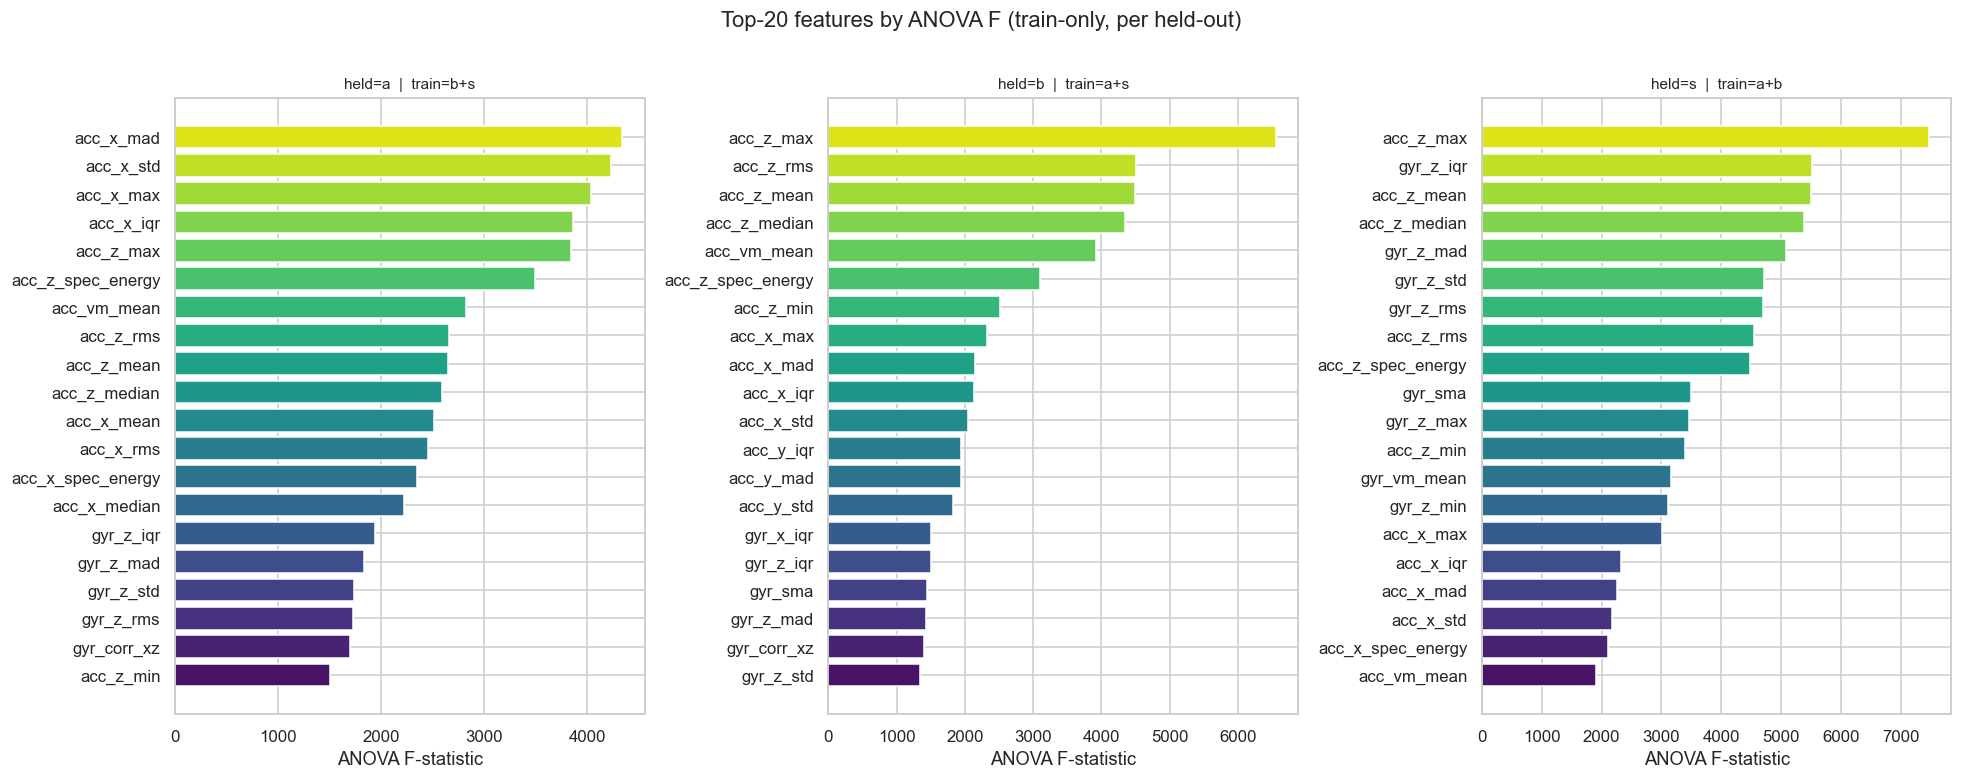


Top-10 ANOVA features for held=a:
          feature           F  p_value
        acc_x_mad 4338.809993      0.0
        acc_x_std 4229.257822      0.0
        acc_x_max 4040.355616      0.0
        acc_x_iqr 3860.176622      0.0
        acc_z_max 3838.619564      0.0
acc_z_spec_energy 3490.898521      0.0
      acc_vm_mean 2819.385397      0.0
        acc_z_rms 2662.532960      0.0
       acc_z_mean 2650.386718      0.0
     acc_z_median 2593.021191      0.0

Top-10 ANOVA features for held=b:
          feature           F  p_value
        acc_z_max 6553.494305      0.0
        acc_z_rms 4506.951838      0.0
       acc_z_mean 4497.633222      0.0
     acc_z_median 4343.431706      0.0
      acc_vm_mean 3927.976965      0.0
acc_z_spec_energy 3102.156850      0.0
        acc_z_min 2513.161778      0.0
        acc_x_max 2316.833321      0.0
        acc_x_mad 2151.297714      0.0
        acc_x_iqr 2127.139040      0.0

Top-10 ANOVA features for held=s:
          feature           F  p_valu

In [4]:
anova_rows = []
fig, axes = plt.subplots(1, len(SUBJECTS), figsize=(6 * len(SUBJECTS), 7),
                          sharex=False)
axes = np.atleast_1d(axes)
for ax, held in zip(axes, SUBJECTS):
    a = folds[held]["anova"]
    save_results(a, f"fe_anova_ranking_held_{held}")
    anova_rows.append(a.assign(held_out=held))
    top20 = a.head(20)
    ax.barh(top20["feature"][::-1], top20["F"][::-1],
            color=sns.color_palette("viridis", 20))
    ax.set_xlabel("ANOVA F-statistic")
    ax.set_title(f"held={held}  |  train={'+'.join(folds[held]['train_subjects'])}",
                 fontsize=10)
fig.suptitle("Top-20 features by ANOVA F (train-only, per held-out)", y=1.01)
fig.tight_layout()
save_figure(fig, "fe_anova_top20_loso")
plt.show()
plt.close(fig)

save_results(pd.concat(anova_rows, ignore_index=True), "fe_anova_ranking_loso")
for held in SUBJECTS:
    print(f"\nTop-10 ANOVA features for held={held}:")
    print(folds[held]["anova"].head(10).to_string(index=False))


# 4. KDE per-class για top features (train-only, per held-out)

## Τι ψάχνουμε σε ένα feature distribution
| Παρατήρηση | Ερμηνεία |
|---|---|
| **Well-separated peaks** | strong discriminative power |
| **Overlapping distributions** | weak feature· χρήσιμο μόνο σε combination |
| **Multi-modal distribution** | sub-patterns εντός class |
| **Long tails / outliers** | sign of artefacts ή ανάγκη για robust scaling |

## Γιατί συμπεριλαμβάνουμε 2 low-F controls
Αν δείξουμε μόνο τα top-6 features, η εικόνα του feature space γίνεται μη ρεαλιστικά αισιόδοξη. Συμπεριλαμβάνουμε τα 2 χαμηλότερα-F features ως **οπτικά controls**.

## Per-fold scope
Παράγουμε ένα KDE figure ανά held-out, διαλέγοντας τα top-6 και bottom-2 features από το train-only ANOVA ranking του ίδιου fold. Έτσι, ούτε η επιλογή των features ούτε οι πυκνότητες που σχεδιάζονται έχουν δει τον test subject.


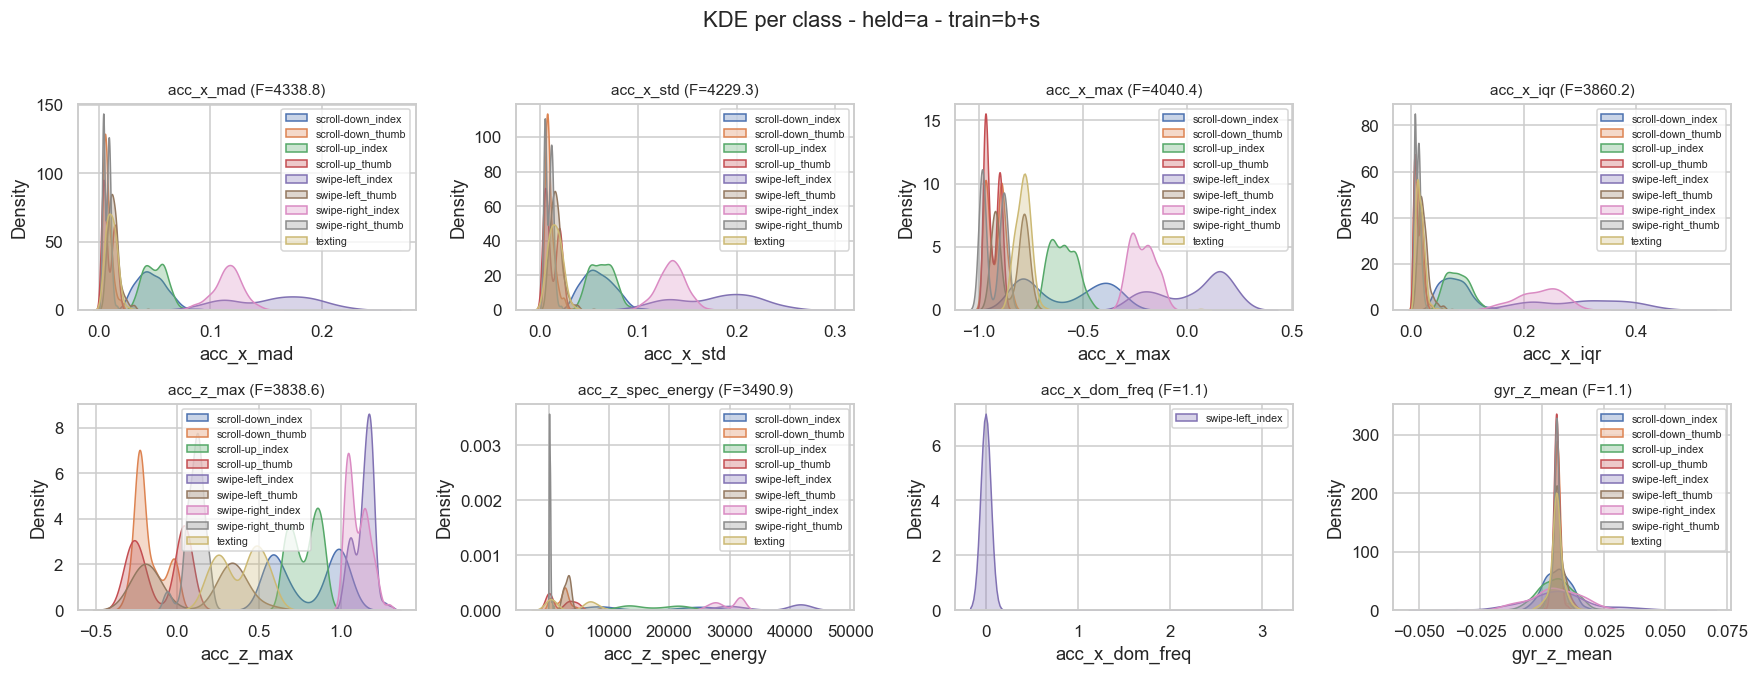

C:\Users\biovo\AppData\Local\Temp\ipykernel_32948\3636036865.py:20: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(fontsize=7)


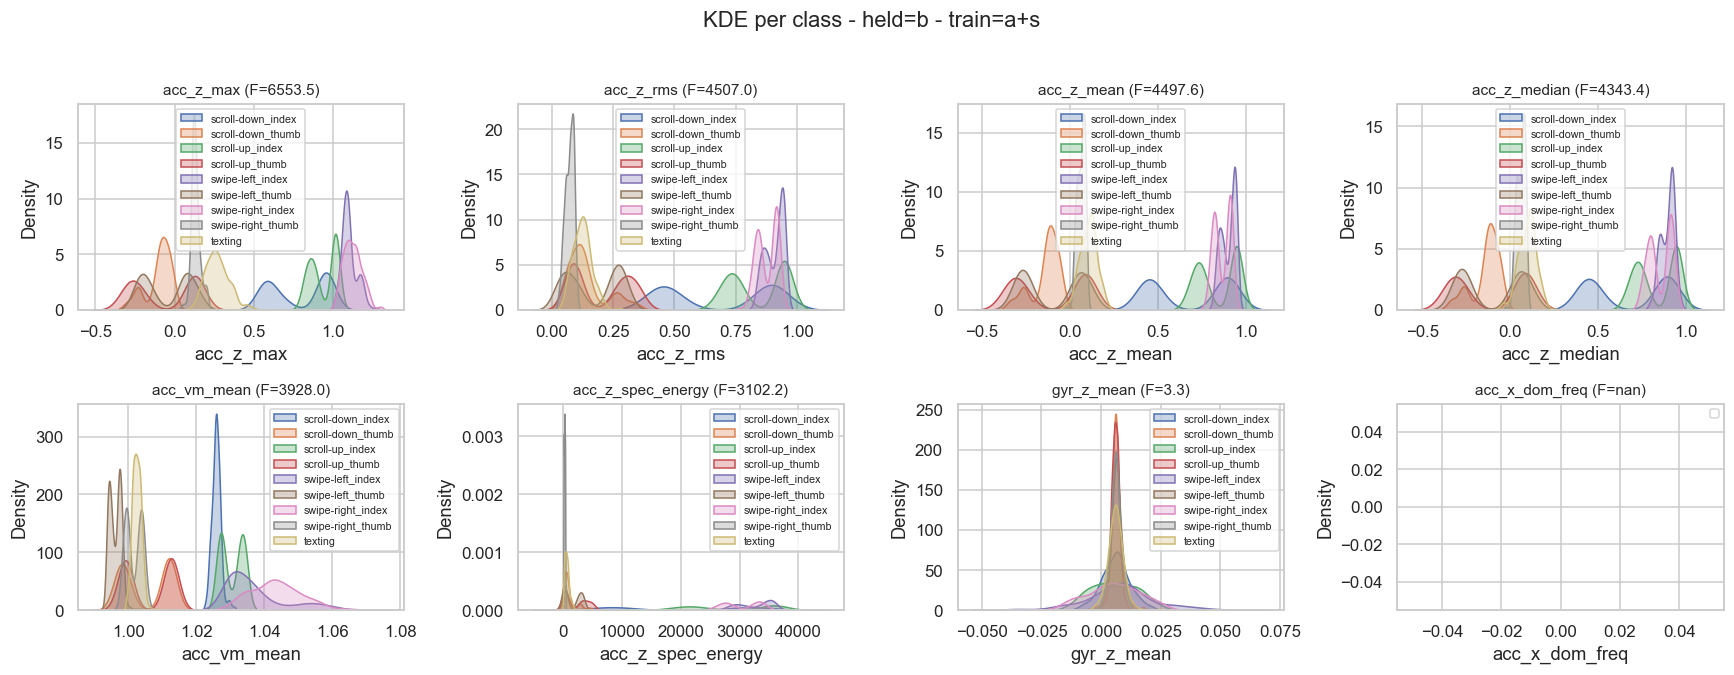

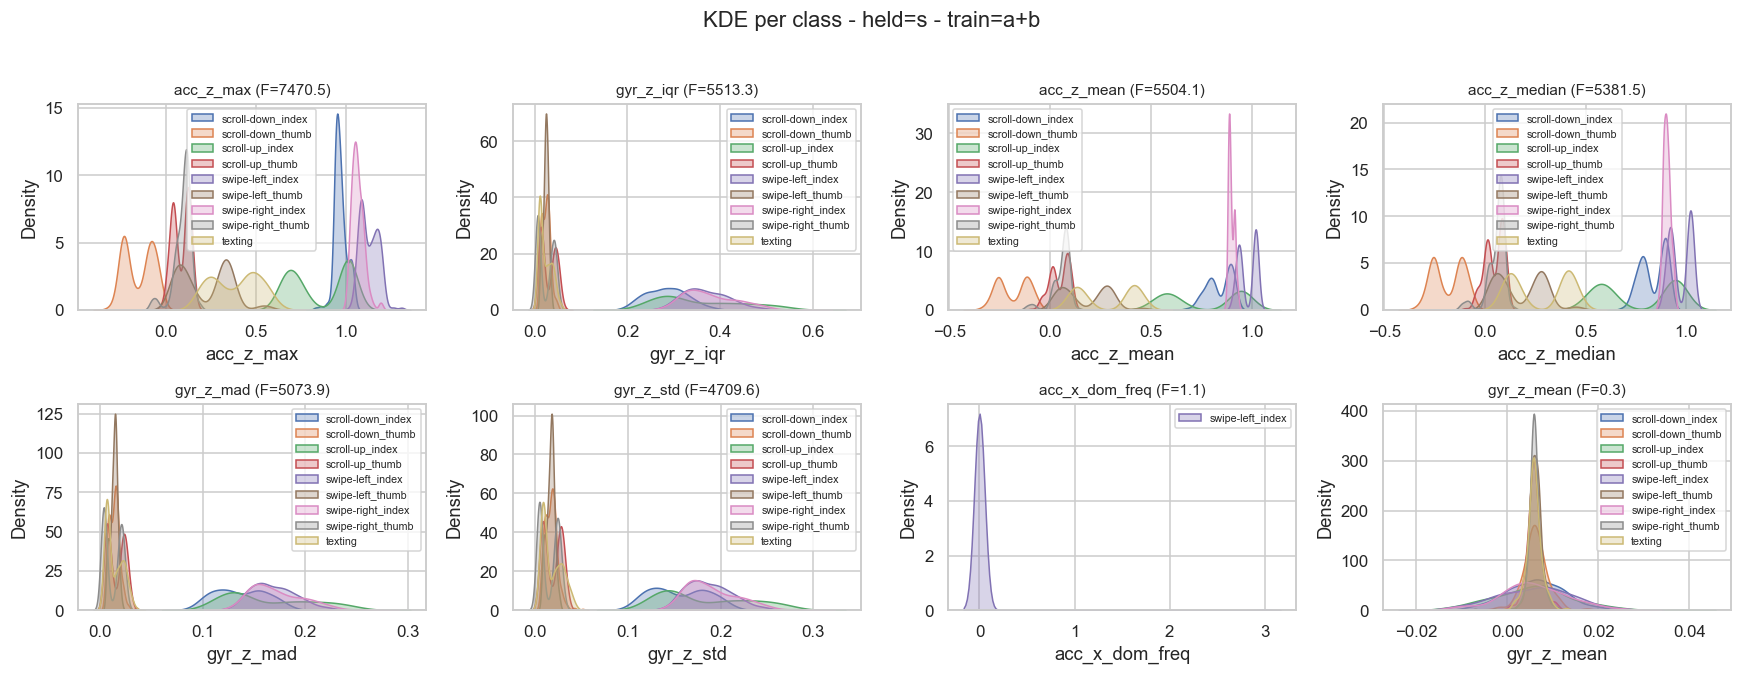

In [5]:
for held in SUBJECTS:
    fold = folds[held]
    X_tr, y_tr, a = fold["X_tr"], fold["y_tr"], fold["anova"]
    top6 = a.head(6)["feature"].tolist()
    low2 = a.tail(2)["feature"].tolist()
    kde_features = top6 + low2

    n_cols = 4
    n_rows = (len(kde_features) + n_cols - 1) // n_cols
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(4 * n_cols, 3 * n_rows))
    axes = np.atleast_2d(axes).ravel()
    classes = sorted(np.unique(y_tr))
    f_lookup = a.set_index("feature")["F"]
    for ax, feat in zip(axes, kde_features):
        for cls in classes:
            sns.kdeplot(X_tr.loc[y_tr == cls, feat], ax=ax,
                        label=cls, fill=True, alpha=0.3,
                        warn_singular=False)
        ax.set_title(f"{feat} (F={f_lookup[feat]:.1f})", fontsize=10)
        ax.legend(fontsize=7)
    for ax in axes[len(kde_features):]:
        ax.set_visible(False)
    fig.suptitle(f"KDE per class - held={held} - train={'+'.join(fold['train_subjects'])}",
                 y=1.02)
    fig.tight_layout()
    save_figure(fig, f"fe_kde_top_features_held_{held}")
    plt.show()
    plt.close(fig)


# 5. Correlation diagnostic (train-only, per held-out)

## Γιατί έχει σημασία η correlation
Δύο features με $|r| > 0.9$ λένε ουσιαστικά το ίδιο πράγμα στο μοντέλο, οδηγώντας σε:
- **Redundant dimensionality**: inflated `D` χωρίς information gain.
- **Multicollinearity**: τα coefficients γραμμικών μοντέλων γίνονται numerically unstable.
- **Wasted compute**: περισσότερα dimensions ⇒ slower training, larger memory footprint.

## Pearson vs Spearman
| Pearson | Spearman | Ερμηνεία |
|---|---|---|
| High | High | True linear relationship |
| Low  | High | Monotonic αλλά non-linear σχέση |
| High | Low  | Outlier-driven correlation |
| Low  | Low  | Genuinely independent features |

Ο `correlation_diagnostic` επιστρέφει `high_pairs` με στήλη `kind` που κατηγοριοποιεί κάθε ζευγάρι.

## Per-fold scope
Υπολογίζουμε ξεχωριστά τα Pearson και Spearman matrices στο train set κάθε fold, καθώς και τη λίστα ζευγαριών πάνω από το threshold. Παράγουμε ένα figure 2×3 (rows = Pearson/Spearman, cols = held-out) και ένα consolidated CSV `fe_correlation_high_pairs_loso.csv` με στήλη `held_out`.

Στο τρέχον dataset, ο αριθμός ζευγαριών με $|r| > 0.95$ είναι: **108 για held=a** (64 linear, 31 monotonic_nonlinear, 13 outlier_driven), **211 για held=b** (126 outlier_driven, 57 linear, 28 monotonic_nonlinear) και **124 για held=s** (77 linear, 30 outlier_driven, 17 monotonic_nonlinear).


held=a: pairs above |r| > 0.95: 108
kind
linear                 64
monotonic_nonlinear    31
outlier_driven         13

  Top 10 'linear' correlated pairs (held=a):
         a                 b  r_pearson  r_spearman
 gyr_x_std         gyr_x_rms   0.999982    0.999928
 gyr_y_std         gyr_y_rms   0.999975    0.999903
 gyr_z_std         gyr_z_rms   0.999971    0.999490
acc_x_mean acc_x_spec_energy  -0.982026   -0.999935
 acc_x_rms acc_x_spec_energy   0.990286    0.999923
acc_x_mean         acc_x_rms  -0.998092   -0.999739
acc_z_mean      acc_z_median   0.999680    0.999067
 acc_z_rms acc_z_spec_energy   0.968326    0.999624
 acc_y_rms acc_y_spec_energy   0.973291    0.999567
 gyr_z_std         gyr_z_mad   0.999324    0.999372

  Top 10 'monotonic_nonlinear' correlated pairs (held=a):
        a                  b  r_pearson  r_spearman
gyr_x_rms  gyr_x_spec_energy   0.937618    0.999937
gyr_y_rms  gyr_y_spec_energy   0.928707    0.999928
gyr_x_std  gyr_x_spec_energy   0.937724    0.999

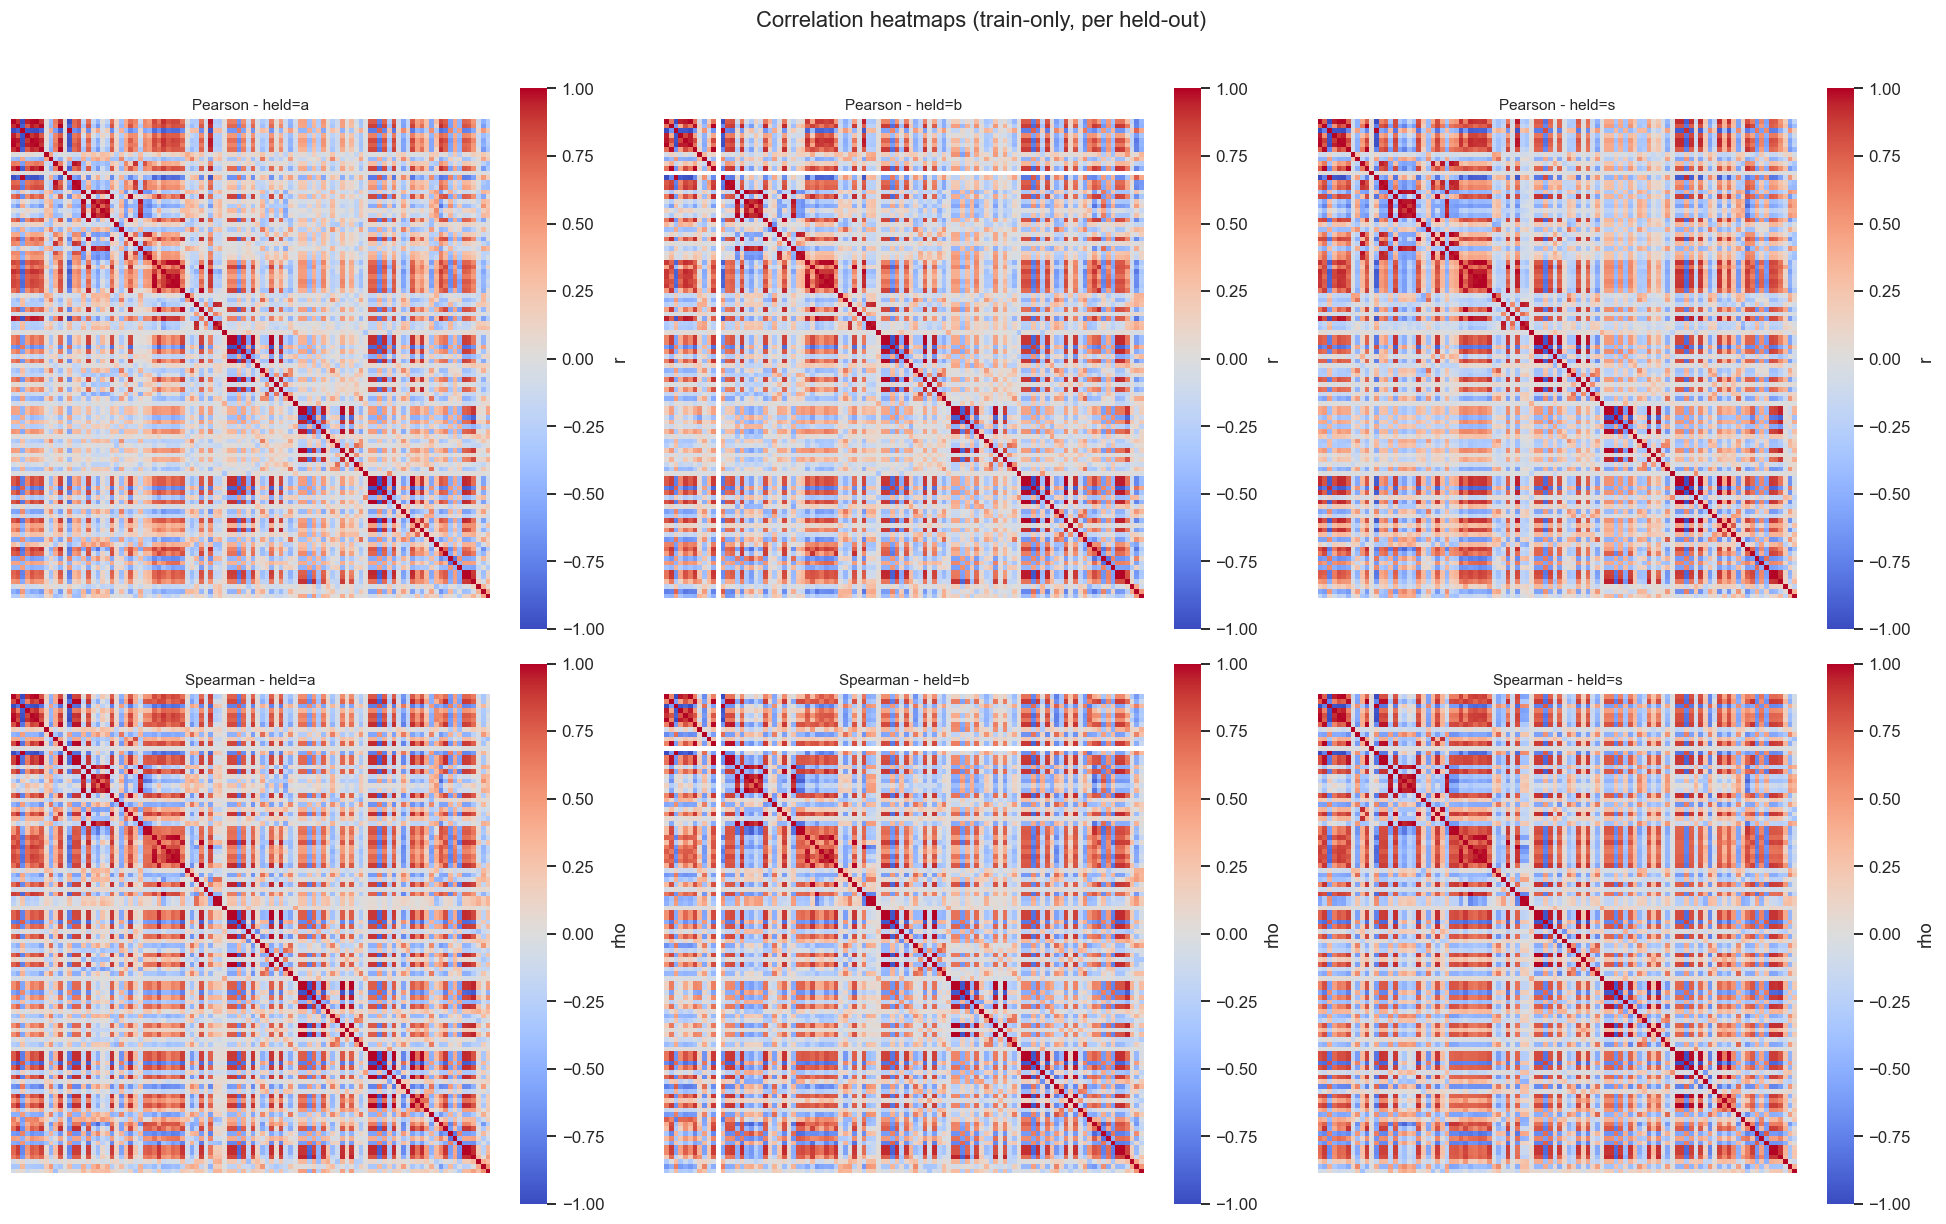

In [6]:
corr_thr = cfg["eda"]["corr_threshold"]
high_pairs_rows = []
fig, axes = plt.subplots(2, len(SUBJECTS), figsize=(6 * len(SUBJECTS), 11))
axes = np.atleast_2d(axes)
for j, held in enumerate(SUBJECTS):
    fold = folds[held]
    diag = correlation_diagnostic(fold["X_tr"], threshold=corr_thr)
    high_pairs = diag["high_pairs"]
    if not high_pairs.empty:
        high_pairs_rows.append(high_pairs.assign(held_out=held))
    print(f"held={held}: pairs above |r| > {corr_thr}: {len(high_pairs)}")
    if not high_pairs.empty:
        print(high_pairs["kind"].value_counts().to_string())
        # Show the actual correlated feature pairs (top 10 by |correlation|)
        # for each kind, so the diagnostic names the features, not just counts.
        for kind in ("linear", "monotonic_nonlinear", "outlier_driven"):
            sub = high_pairs[high_pairs["kind"] == kind].head(10)
            if sub.empty:
                continue
            print()
            print(f"  Top {len(sub)} '{kind}' correlated pairs (held={held}):")
            print(sub[["a", "b", "r_pearson", "r_spearman"]]
                  .to_string(index=False))
        print()

    sns.heatmap(diag["pearson"], ax=axes[0, j], cmap="coolwarm", center=0,
                vmin=-1, vmax=1, square=True, xticklabels=False, yticklabels=False,
                cbar_kws={"label": "r"})
    axes[0, j].set_title(f"Pearson - held={held}", fontsize=10)
    sns.heatmap(diag["spearman"], ax=axes[1, j], cmap="coolwarm", center=0,
                vmin=-1, vmax=1, square=True, xticklabels=False, yticklabels=False,
                cbar_kws={"label": "rho"})
    axes[1, j].set_title(f"Spearman - held={held}", fontsize=10)
fig.suptitle("Correlation heatmaps (train-only, per held-out)", y=1.01)
fig.tight_layout()
save_figure(fig, "fe_correlation_heatmaps_loso")
plt.show()
plt.close(fig)

if high_pairs_rows:
    save_results(pd.concat(high_pairs_rows, ignore_index=True),
                 "fe_correlation_high_pairs_loso")
else:
    save_results(pd.DataFrame(columns=["feature_a", "feature_b", "r", "rho", "kind", "held_out"]),
                 "fe_correlation_high_pairs_loso")


# 6. Pairwise scatter για top-k (train-only, per held-out)

## Από 1D σε 2D separability
Ένα feature που διαχωρίζει αδύναμα τις classes στο 1D μπορεί να διαχωρίζει καλά σε **συνδυασμό** με ένα άλλο feature. Το pairwise scatter αποκαλύπτει αυτή την joint separability που είναι αόρατη στα KDE plots.

## Combinatorial challenge και η λύση
Με 102 features υπάρχουν $\binom{102}{2} = 5{,}151$ μοναδικά ζεύγη. Επιλέγουμε τα top-`k` features με βάση το ANOVA F-score (`cfg.eda.anova_top_k = 10`) και σχεδιάζουμε $\binom{k}{2} = 45$ panels + 10 διαγώνια KDEs σε ένα grid $10\times 10$.

## Per-fold scope
Παράγουμε ένα scatter figure ανά held-out, με τα top-k features υπολογισμένα από το train-only ANOVA ranking του ίδιου fold. Τα clouds που σχεδιάζονται προέρχονται μόνο από τα 2 train subjects.


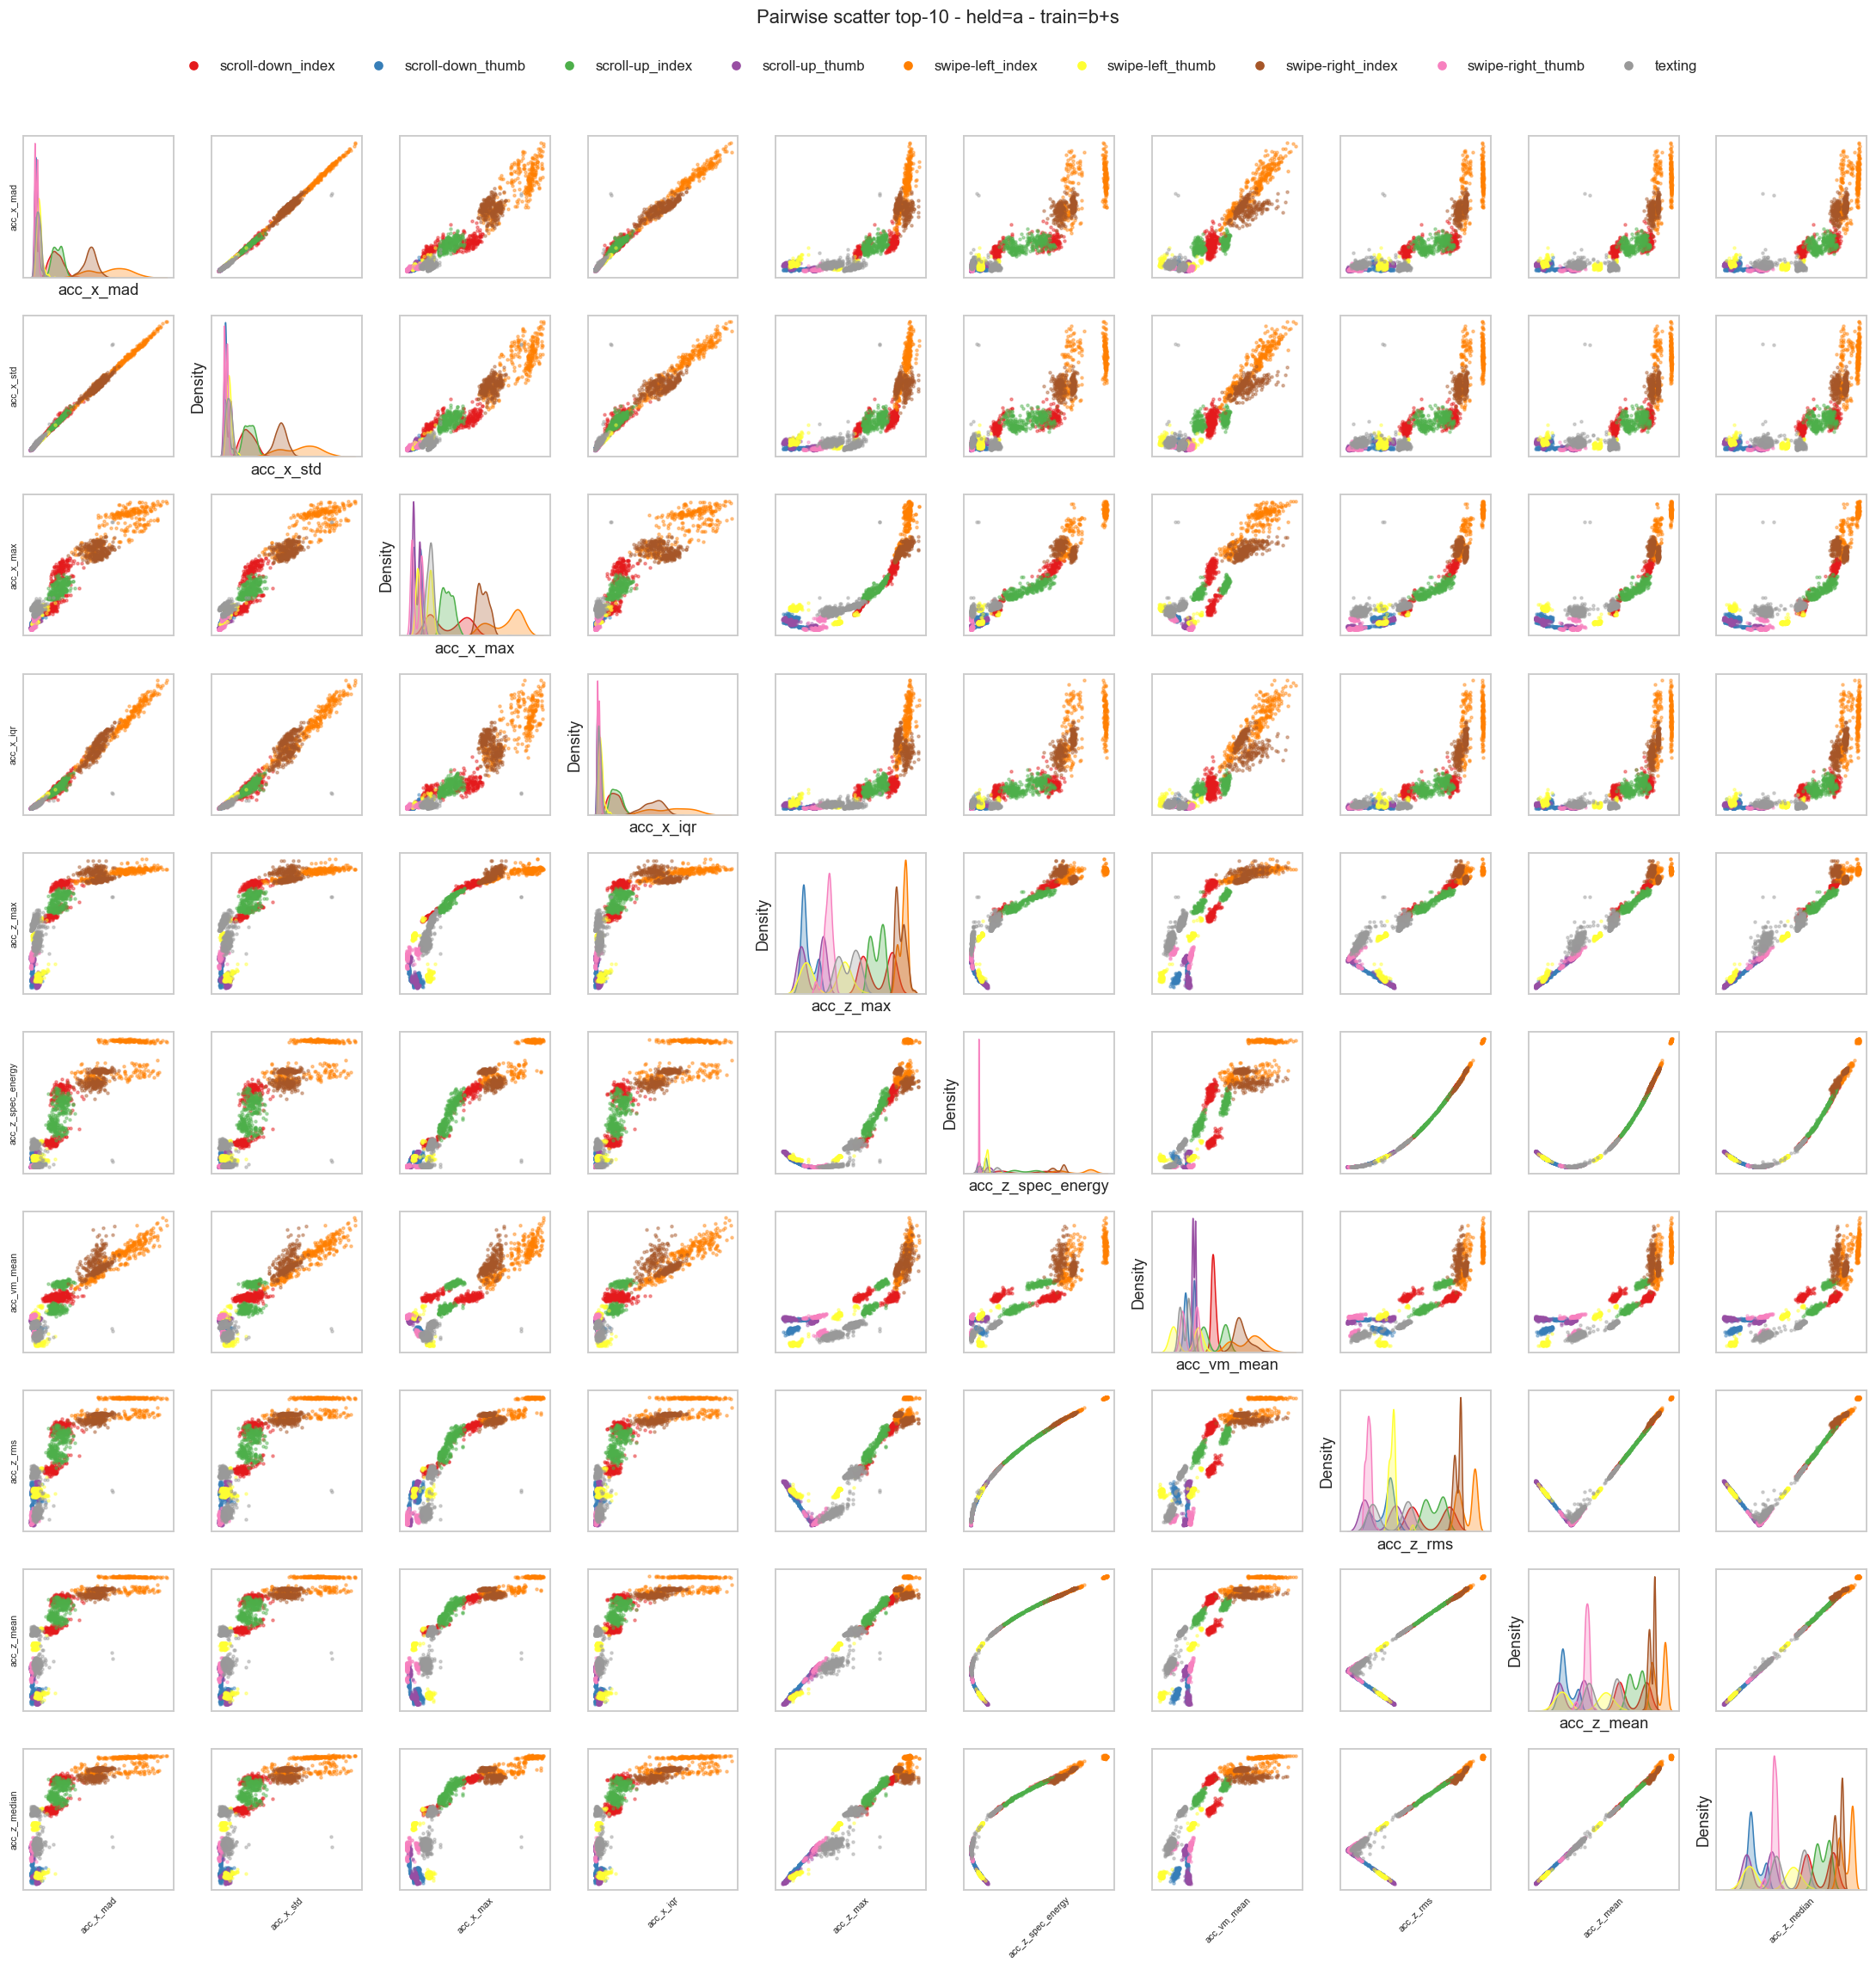

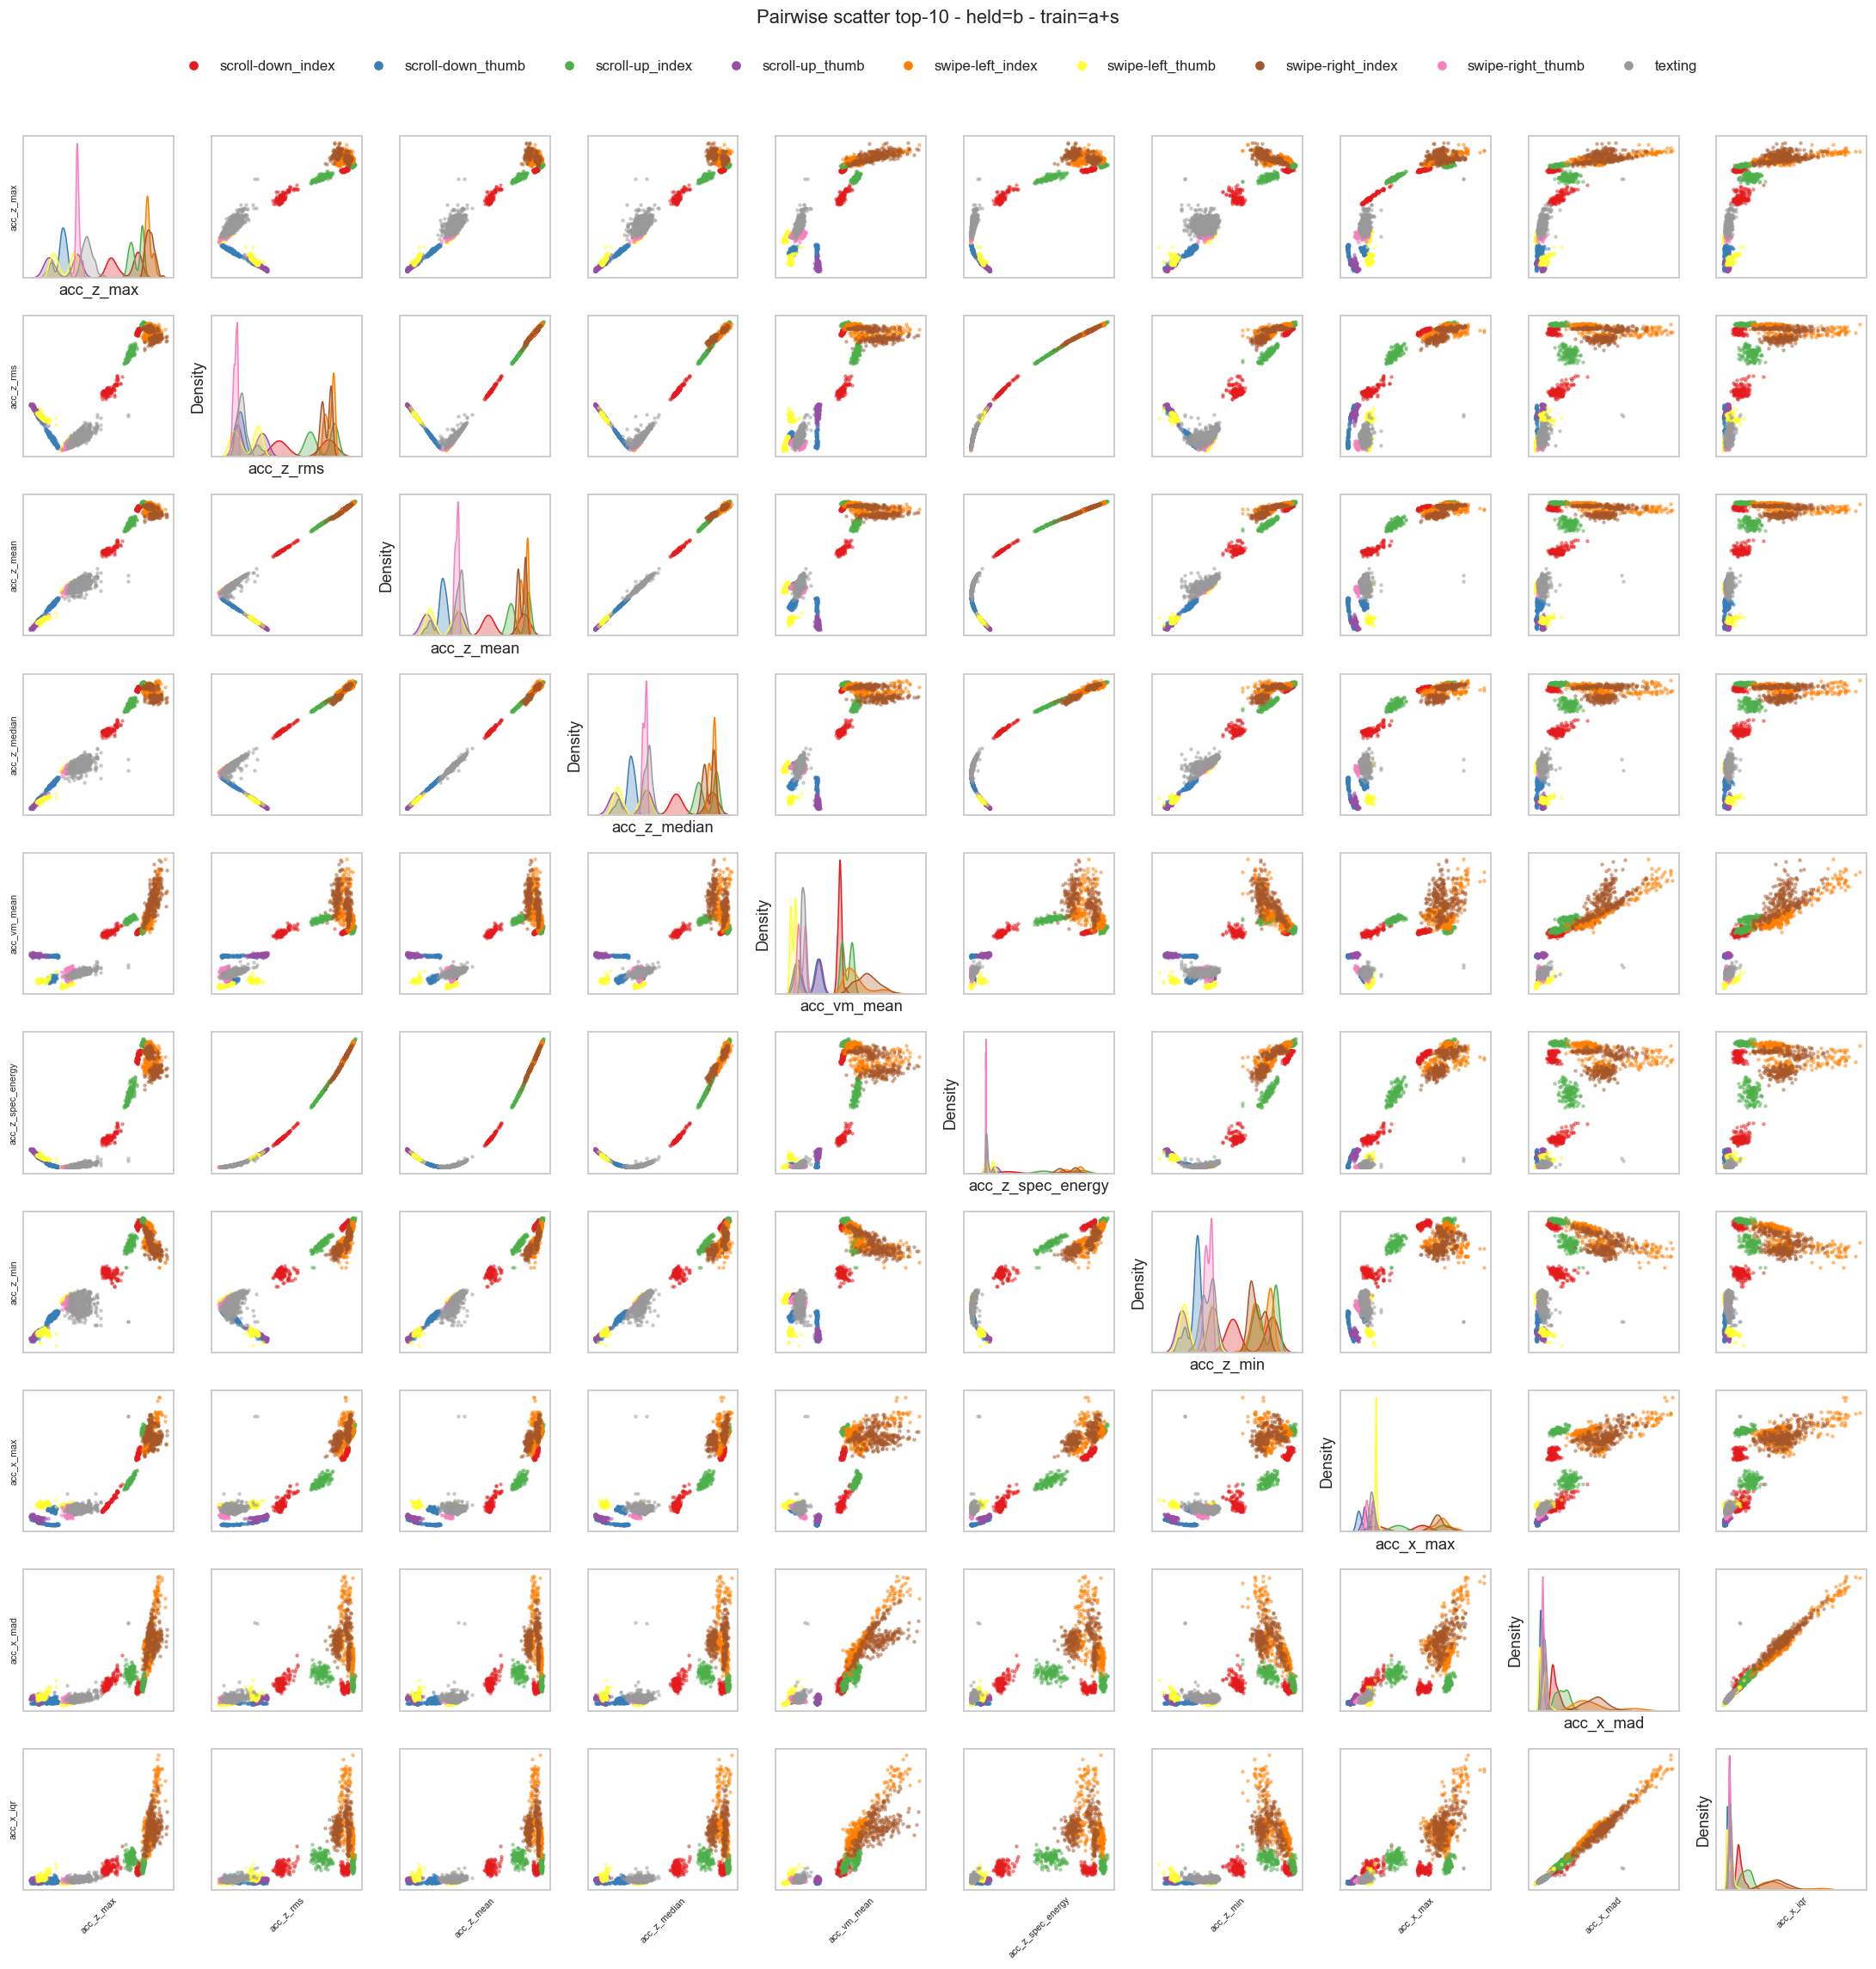

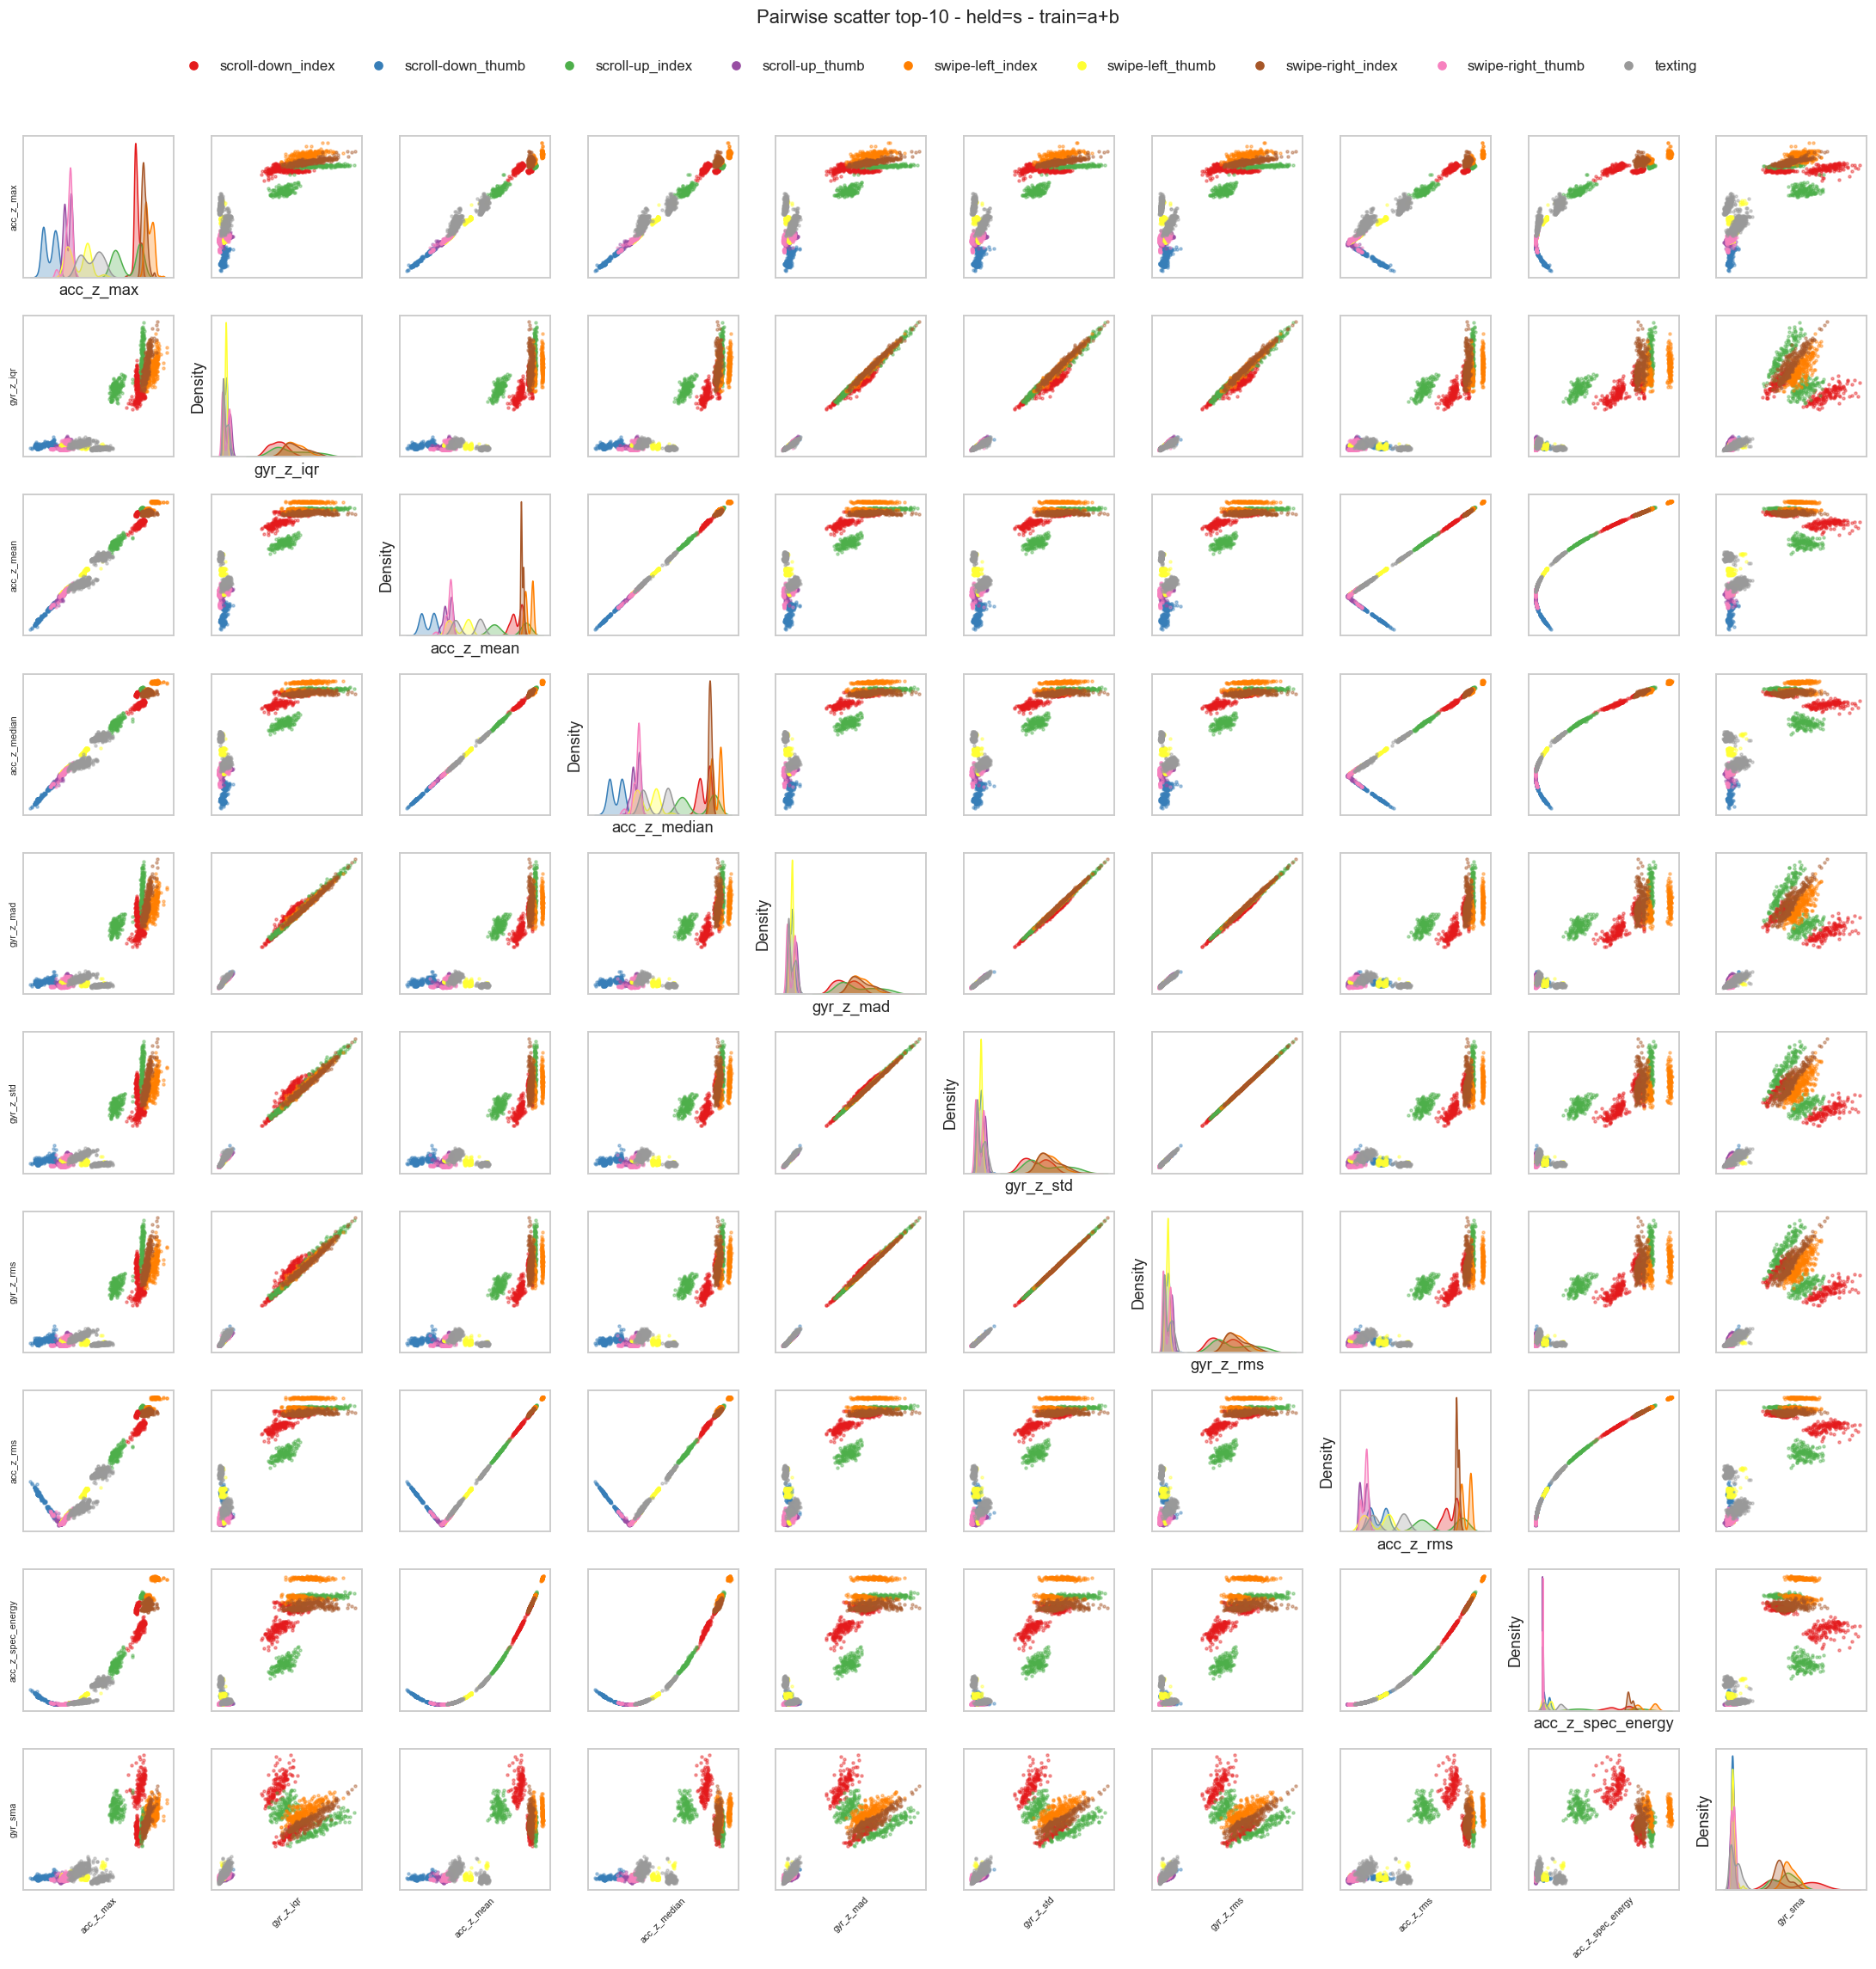

In [7]:
top_k = cfg["eda"]["anova_top_k"]
for held in SUBJECTS:
    fold = folds[held]
    X_tr, y_tr, a = fold["X_tr"], fold["y_tr"], fold["anova"]
    scatter_feats = a.head(top_k)["feature"].tolist()
    classes = sorted(np.unique(y_tr))
    palette = sns.color_palette("Set1", n_colors=len(classes))
    n = len(scatter_feats)
    fig, axes = plt.subplots(n, n, figsize=(2 * n, 2 * n))
    for i, fi in enumerate(scatter_feats):
        for j, fj in enumerate(scatter_feats):
            ax = axes[i, j]
            if i == j:
                for cls, c in zip(classes, palette):
                    sns.kdeplot(X_tr.loc[y_tr == cls, fi], ax=ax,
                                color=c, fill=True, alpha=0.3,
                                warn_singular=False)
            else:
                for cls, c in zip(classes, palette):
                    mask = y_tr == cls
                    ax.scatter(X_tr.loc[mask, fj], X_tr.loc[mask, fi],
                               s=4, alpha=0.4, color=c)
            ax.set_xticks([]); ax.set_yticks([])
            if i == n - 1: ax.set_xlabel(fj, fontsize=7, rotation=45)
            if j == 0:     ax.set_ylabel(fi, fontsize=7)
    handles = [plt.Line2D([], [], marker="o", linestyle="", color=c, label=cls)
               for cls, c in zip(classes, palette)]
    fig.legend(handles=handles, loc="upper center", ncol=len(classes),
               bbox_to_anchor=(0.5, 1.02), frameon=False)
    fig.suptitle(f"Pairwise scatter top-{top_k} - held={held} - "
                 f"train={'+'.join(fold['train_subjects'])}", y=1.04)
    fig.tight_layout()
    save_figure(fig, f"fe_scatter_top{top_k}_held_{held}")
    plt.show()
    plt.close(fig)


# 7. Box plots per class (train-only, per held-out)

## Anatomy ενός box plot
- **Box**: από $Q_{25}$ έως $Q_{75}$ (το μεσαίο 50% των δεδομένων, IQR).
- **Median line**: $Q_{50}$ εντός του box.
- **Whiskers**: συνήθως από $Q_{25} - 1.5\cdot \mathrm{IQR}$ έως $Q_{75} + 1.5\cdot \mathrm{IQR}$.
- **Points beyond whiskers**: outliers.

## Διαβάζοντας το αποτέλεσμα
| Παρατήρηση | Ερμηνεία |
|---|---|
| **Non-overlapping boxes per class** | strong class separation |
| **Overlapping boxes** | partial usefulness |
| **Identical distributions** | το feature είναι useless για το συγκεκριμένο class pair |
| **Πολλοί outliers** | heavy-tailed distribution ⇒ Robust Scaler upstream |

## Σύνδεση με τη scaling στρατηγική
Ο `ColumnTransformer` στο modeling cell χρησιμοποιεί `StandardScaler` για τα `acc_` features και `RobustScaler` για τα `gyr_` features, δικαιολογημένα από τα heavy tails των gyroscope-derived features.

## Per-fold scope
Παράγουμε ένα box plot figure ανά held-out, με τα top-6 features από το train-only ANOVA ranking του fold.


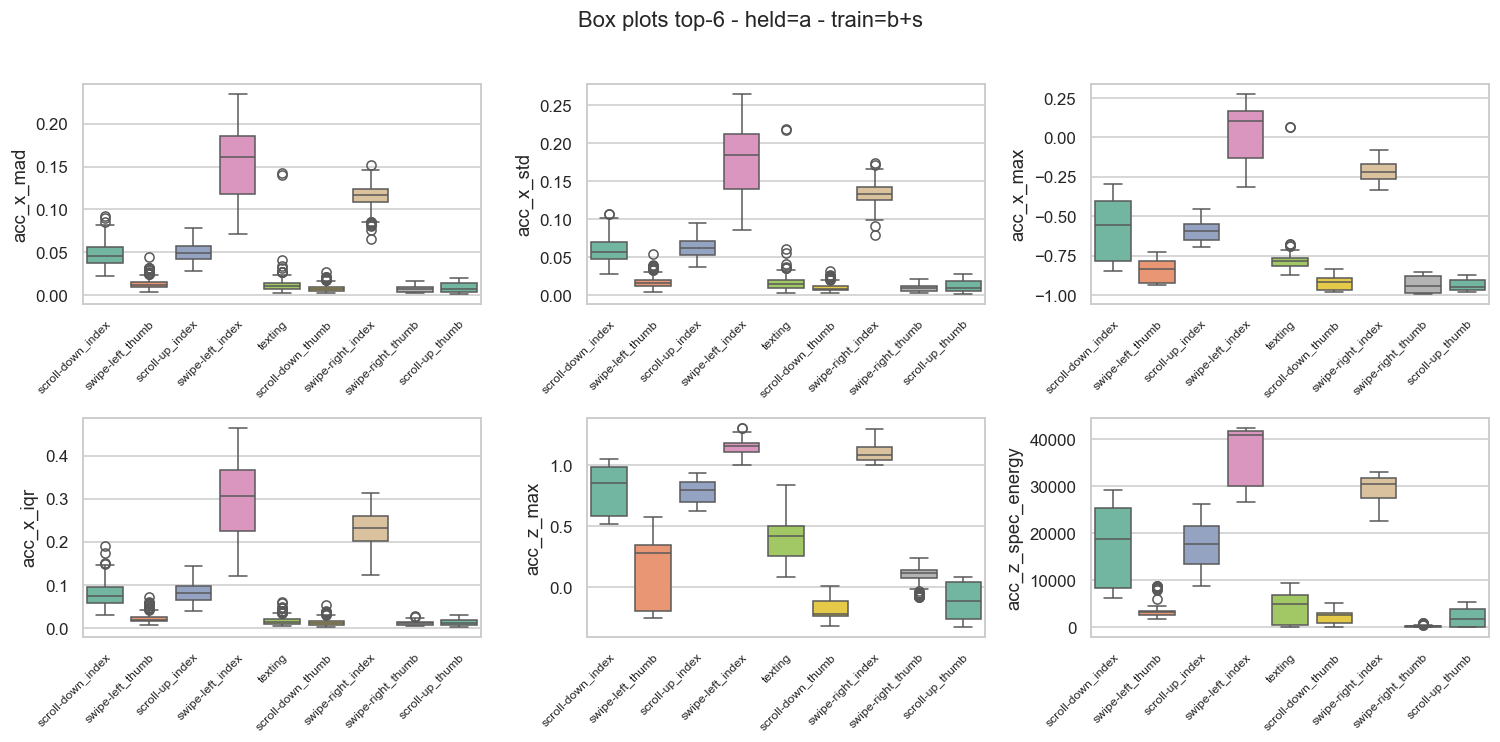

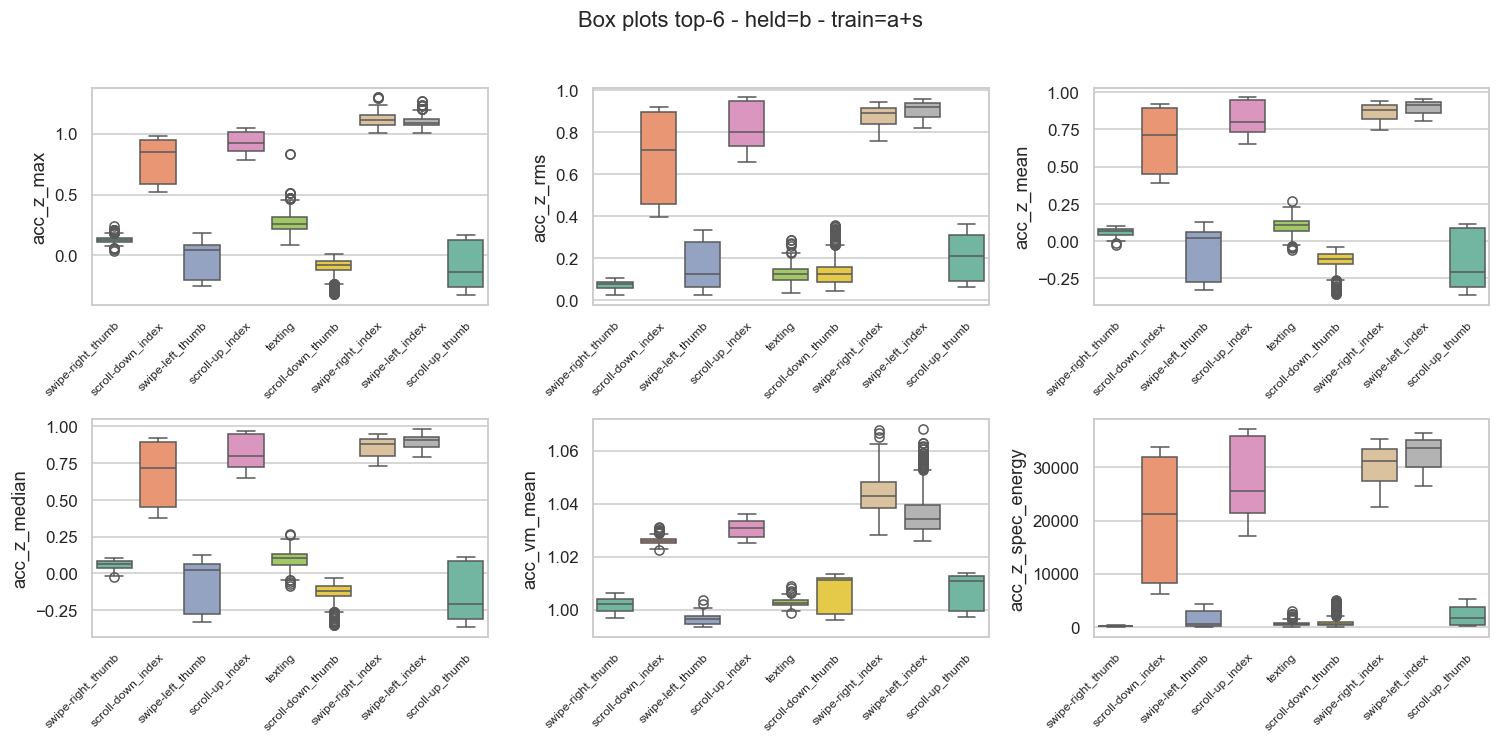

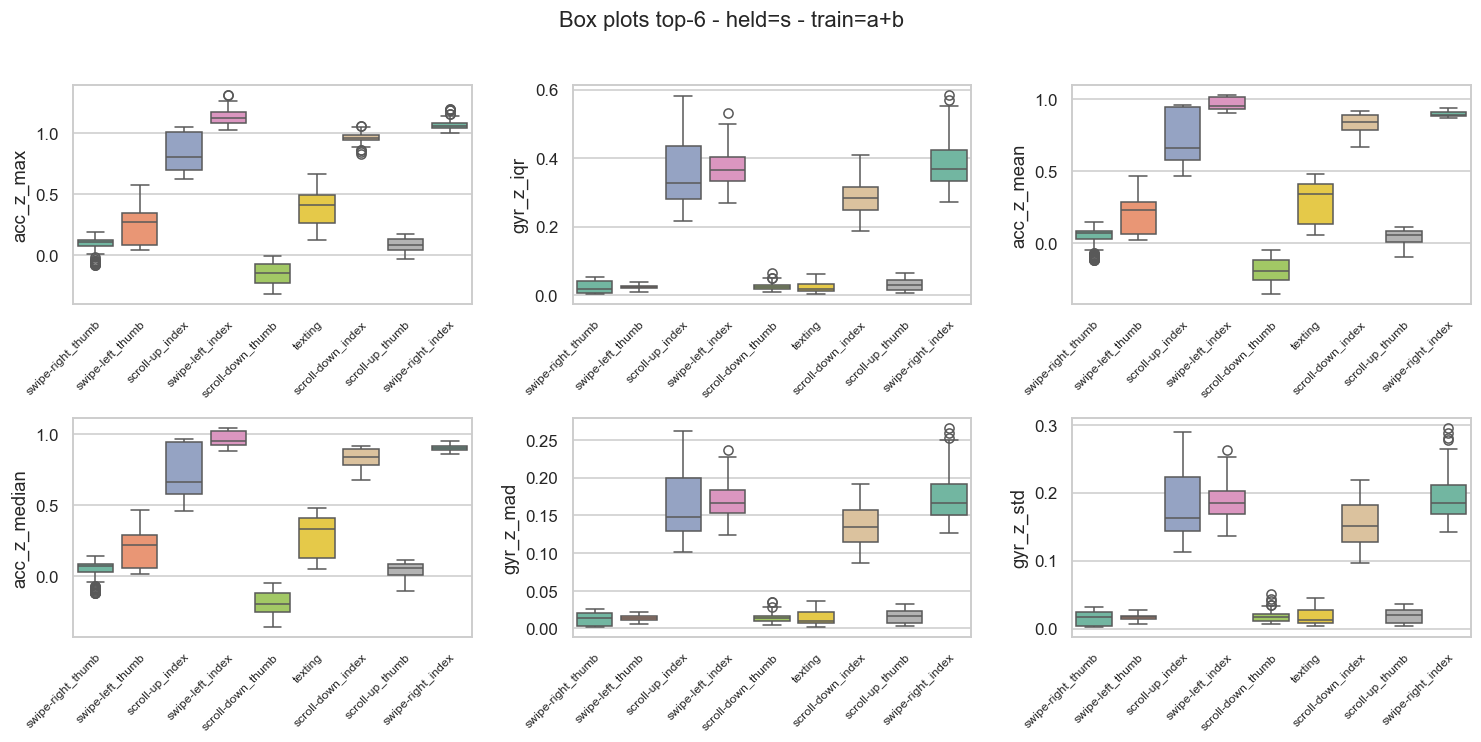

In [8]:
for held in SUBJECTS:
    fold = folds[held]
    X_tr, y_tr, a = fold["X_tr"], fold["y_tr"], fold["anova"]
    box_features = a.head(6)["feature"].tolist()
    n_cols = 3
    n_rows = (len(box_features) + n_cols - 1) // n_cols
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(4.6 * n_cols, 3.3 * n_rows))
    axes = np.atleast_2d(axes).ravel()
    df_long = X_tr.copy()
    df_long["__y"] = y_tr
    for ax, feat in zip(axes, box_features):
        sns.boxplot(data=df_long, x="__y", y=feat, ax=ax,
                    hue="__y", palette="Set2", legend=False)
        ax.set_xlabel("")
        ax.set_ylabel(feat)
        plt.setp(ax.get_xticklabels(), rotation=45, ha="right",
                 rotation_mode="anchor")
        ax.tick_params(axis="x", labelsize=8)
    for ax in axes[len(box_features):]:
        ax.set_visible(False)
    fig.suptitle(f"Box plots top-6 - held={held} - train={'+'.join(fold['train_subjects'])}",
                 y=1.02)
    fig.tight_layout()
    save_figure(fig, f"fe_box_per_class_top6_held_{held}")
    plt.show()
    plt.close(fig)


# 8. PCA: cumulative EVR + 2D scatter (train-only, per held-out)

## Η ιδέα
Στόχος: συμπίεση `F` διαστάσεων σε $k \ll F$ με τη λιγότερη δυνατή απώλεια πληροφορίας. Κάθε principal component είναι weighted blend όλων των features:

$$PC_k \;=\; \sum_{i} w_{k,i}\, x_i$$

Τα βάρη $w_k$ μεγιστοποιούν την προβολή της variance, με $\lVert w_k \rVert = 1$ και $w_k \perp w_1, \ldots, w_{k-1}$.

## Τα 4 βήματα του PCA
1. **Centre**: $\tilde{X} = X - \bar{x}$.
2. **Covariance matrix**: $\Sigma = \tfrac{1}{N-1}\,\tilde{X}^{\top}\tilde{X} \in \mathbb{R}^{F\times F}$.
3. **Eigendecomposition**: $\Sigma w_k = \lambda_k w_k$.
4. **Project + EVR**: $Z = \tilde{X}\,V_k$, με $\mathrm{EVR}_k = \lambda_k / \sum_{j}\lambda_j$.

## Per-fold scope
Το fit του `StandardScaler` και του `PCA` γίνεται **μόνο στο train** του εκάστοτε fold. Παράγουμε ένα figure 2×3 (rows = cumulative EVR, 2D scatter, cols = held-out). Έτσι ούτε ο scaler ούτε τα principal components έχουν δει τον test subject.

Για να καλυφθεί 95% της variance χρειάζονται **27 components για held=a**, **28 για held=b** και **27 για held=s** - δηλαδή το PCA συμπιέζει το αρχικό feature space (102 διαστάσεις) σε περίπου το ένα τέταρτο.

## Κρίσιμος περιορισμός
Το PCA μεγιστοποιεί **variance**, όχι class separation. **PCA failure ≠ model failure**.


held=a: components retaining 95% EVR: 27
held=b: components retaining 95% EVR: 28
held=s: components retaining 95% EVR: 27


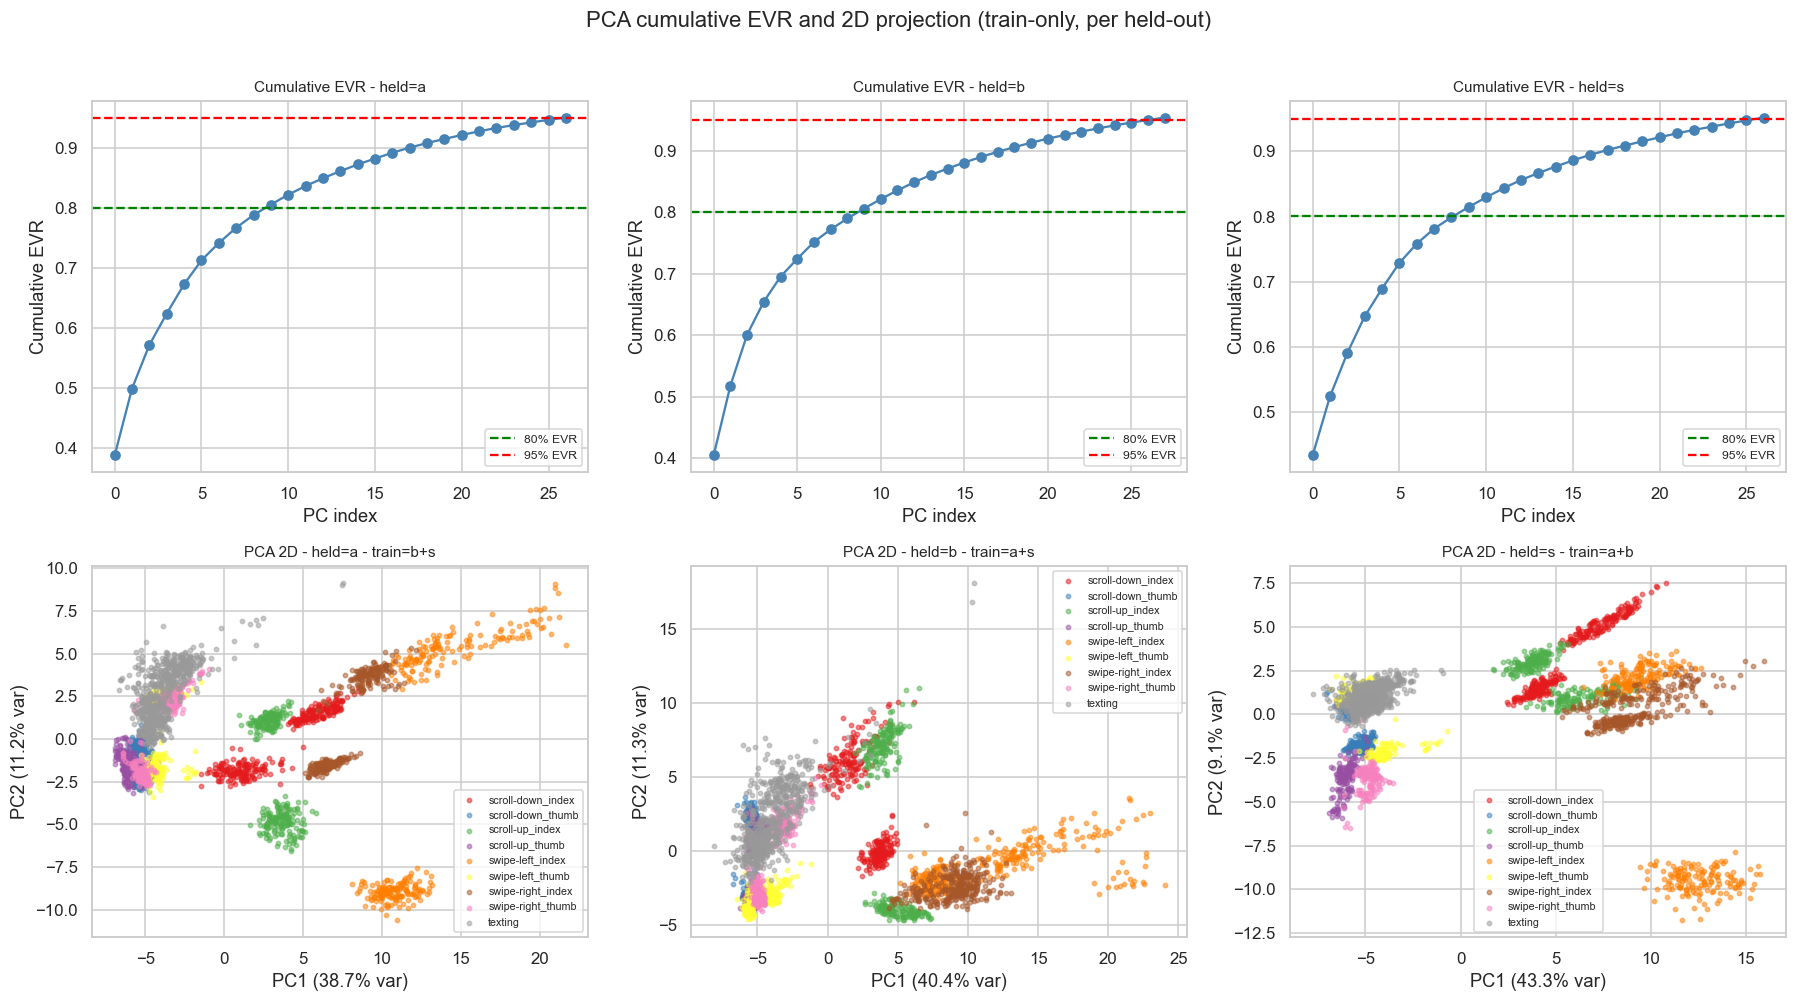

In [9]:
evr_threshold = cfg["eda"]["pca_evr_threshold"]
fig, axes = plt.subplots(2, len(SUBJECTS), figsize=(5.5 * len(SUBJECTS), 9))
axes = np.atleast_2d(axes)
for j, held in enumerate(SUBJECTS):
    fold = folds[held]
    X_tr, y_tr = fold["X_tr"], fold["y_tr"]
    X_tr_z = StandardScaler().fit_transform(X_tr)
    pca_full = PCA(n_components=evr_threshold).fit(X_tr_z)
    print(f"held={held}: components retaining {evr_threshold * 100:.0f}% EVR: "
          f"{pca_full.n_components_}")

    ax_top = axes[0, j]
    ax_top.plot(np.cumsum(pca_full.explained_variance_ratio_), marker="o",
                color="steelblue")
    ax_top.axhline(0.80, color="green", ls="--", label="80% EVR")
    ax_top.axhline(0.95, color="red",   ls="--", label="95% EVR")
    ax_top.set_xlabel("PC index")
    ax_top.set_ylabel("Cumulative EVR")
    ax_top.legend(fontsize=8)
    ax_top.set_title(f"Cumulative EVR - held={held}", fontsize=10)

    pca_2d_model = PCA(n_components=2).fit(X_tr_z)
    pca_2d = pca_2d_model.transform(X_tr_z)
    classes = sorted(np.unique(y_tr))
    palette = sns.color_palette("Set1", len(classes))
    ax_bot = axes[1, j]
    for cls, c in zip(classes, palette):
        mask = y_tr == cls
        ax_bot.scatter(pca_2d[mask, 0], pca_2d[mask, 1], s=8, alpha=0.5,
                       color=c, label=cls)
    evr = pca_2d_model.explained_variance_ratio_
    ax_bot.set_xlabel(f"PC1 ({evr[0] * 100:.1f}% var)")
    ax_bot.set_ylabel(f"PC2 ({evr[1] * 100:.1f}% var)")
    ax_bot.legend(fontsize=7)
    ax_bot.set_title(f"PCA 2D - held={held} - train={'+'.join(fold['train_subjects'])}",
                     fontsize=10)
fig.suptitle("PCA cumulative EVR and 2D projection (train-only, per held-out)", y=1.01)
fig.tight_layout()
save_figure(fig, "fe_pca_evr_and_2d_loso")
plt.show()
plt.close(fig)


# 9. Correlation pruning summary (train-only, per held-out)

## Στρατηγική: drop the lower-F member
Για κάθε ζευγάρι features με $|r| > 0.95$ κρατάμε αυτό με το μεγαλύτερο ANOVA F. Διατηρεί το semantic identity των features και είναι πλήρως interpretable. Εναλλακτικές είναι το PCA (cell 12) ή tree-based models λιγότερο sensitive σε multicollinearity.

## Edge case: constant features
Ο helper `find_highly_correlated` αφαιρεί upfront τα features με μη πεπερασμένο F (zero-variance columns σε κάποιο fold) και αγνοεί ζευγάρια με NaN correlation. Έτσι αποφεύγεται cascade pruning λόγω σιωπηρών NaN συγκρίσεων.

## Τι κάνει αυτό το cell
Συνοψίζει τις per-fold drop lists που υπολογίστηκαν στο cell 2b (train-only, ανά held-out). Δεν υπάρχει "reference" drop list σε ολόκληρο το dataset, γιατί κάτι τέτοιο θα είχε δει τα labels του held-out subject (το ANOVA F είναι supervised). Το consolidated CSV έχει στήλες `held_out`, `dropped_feature`, ώστε το report να μπορεί να αντιπαραβάλει τις drop lists ανά fold.

Συνολικά αφαιρούνται **34 features για held=a**, **39 για held=b** και **44 για held=s** (από τα 102 αρχικά). Τα samples/features ratios μετά το pruning είναι 44.3, 47.5 και 51.9 αντίστοιχα - υγιή και στις τρεις folds.


In [10]:
drop_rows = []
for held in SUBJECTS:
    fold = folds[held]
    for f in fold["drops"]:
        drop_rows.append({"held_out": held, "dropped_feature": f})
    samples_per_feature = fold["X_tr_p"].shape[0] / max(fold["X_tr_p"].shape[1], 1)
    print(f"held={held}: dropped {len(fold['drops'])} of {fold['X_tr'].shape[1]} features"
          f"  |  samples/features after pruning = {samples_per_feature:.1f}")

drop_df = pd.DataFrame(drop_rows)
save_results(drop_df, "fe_dropped_correlated_loso")

# Cross-fold agreement: which features get dropped in all 3, in 2, in 1 fold?
if not drop_df.empty:
    counts = drop_df.groupby("dropped_feature")["held_out"].count().sort_values(ascending=False)
    print("\nDrop frequency across folds (3 = dropped in every fold):")
    print(counts.head(20).to_string())


held=a: dropped 34 of 102 features  |  samples/features after pruning = 44.3
held=b: dropped 39 of 102 features  |  samples/features after pruning = 47.5
held=s: dropped 44 of 102 features  |  samples/features after pruning = 51.9

Drop frequency across folds (3 = dropped in every fold):
dropped_feature
acc_x_max            3
acc_x_median         3
acc_x_mean_freq      3
acc_x_mean           3
acc_y_median         3
acc_y_mean           3
acc_y_rms            3
acc_x_rms            3
acc_x_std            3
acc_x_spec_energy    3
acc_y_mad            3
gyr_y_rms            3
acc_z_std            3
gyr_x_max            3
gyr_x_mad            3
gyr_vm_mean          3
acc_z_mean           3
acc_z_median         3
acc_z_min            3
acc_z_mad            3


# 10. Leave-one-subject-out modeling

## Αλλαγή στρατηγικής: από single split σε LOSO

### Η αρχική προσέγγιση
Ο αρχικός σχεδιασμός όριζε **subject-based single split**: train σε users `a` και `b`, test σε user `s`, με στόχο `f1_macro ≥ 0.60`. Η επιλογή subject-based split (αντί random shuffle) ακολουθούσε τη βιβλιογραφία για αποφυγή του **window leakage**.

### Τι παρατηρήσαμε
Με το single split `a+b → s` και τις 9 classes: SVM-RBF `f1_macro = 0.401`, RF `f1_macro = 0.265`. Πολύ κάτω από τον στόχο 0.60.

### Diagnostic deep-dive
1. **Within-subject sanity** - train + test μόνο στον user `a` με random 80/20 stratified split → `f1_macro = 1.000`. Τα features **είναι** discriminative.
2. **Pairwise transfer** - train σε ένα subject, test σε άλλο: τα αποτελέσματα κυμαίνονται από 0.20 ως 0.45.
3. **Ruled out hypotheses**: per-window DC removal, αφαίρεση orientation-pose features - κανένα δεν έκλεισε το gap.

### Συμπέρασμα
Η **inter-subject variance** υπερβαίνει την inter-class variance. Με μόνο **3 subjects**, το μοντέλο **δεν μπορεί** να μάθει subject-invariant representation. Δεν πρόκειται για modeling bug· είναι θεμελιώδης περιορισμός του dataset.

### Γιατί LOSO (leave-one-subject-out)
Ένα μόνο test score σε έναν subject είναι noisy point estimate. Η LOSO τρέχει K = 3 fits, με κάθε subject να παίζει σειρά ως held-out test:
- `(b, s) → a`
- `(a, s) → b`
- `(a, b) → s`

Το reporting δίνει **per-fold breakdown + LOSO mean**, αντί για ένα point estimate που εξαρτάται από το ποιον subject τυχαίνει να έχουμε held-out.

## Per-fold αυστηρή απουσία leakage
Όλα τα precomputed artifacts (ANOVA ranking, drop list, pruned matrices) έχουν ήδη παραχθεί στο cell 2b με `fit` αποκλειστικά στο train κάθε fold. Εδώ:
1. Παίρνουμε τα `X_tr_p`, `X_te_p`, `y_tr`, `y_te`, `groups_tr` από το dict `folds[held]`.
2. Φτιάχνουμε per-fold `ColumnTransformer` (`StandardScaler` για `acc_*`, `RobustScaler` για `gyr_*`) μέσα σε `Pipeline`. Ο scaler κάνει `fit` **μόνο** στο train.
3. `GridSearchCV(GroupKFold(n_splits=2))` με `scoring='f1_macro'`. Με 2 train subjects, το `GroupKFold(2)` είναι ακριβώς leave-one-subject-out **εντός** του train (nested LOSO για hyperparameter selection).
4. `refit=True` πάνω σε όλο το train, `predict` στον held-out subject **μία φορά**.

Δοκιμάζονται **τέσσερις classifiers**: SVM-RBF, Random Forest, Gradient Boosting, Logistic Regression - 4 μοντέλα × 3 folds = **12 fits** συνολικά.

## Σημαντική παρατήρηση για το CV scoring
Με μόνο 2 training subjects, το inner CV είναι noisy και τείνει να επιλέγει τα **πιο regularized** hyperparameters. Δεν είναι bug· είναι ένδειξη ότι ο grid scorer ανταμείβει flat decision surfaces, γιατί οι 2 train subjects διαφωνούν τοπικά.


In [11]:
# Four classifiers under the same subject-aware LOSO scheme.
# tune_feature_classifier builds Pipeline([pre, clf]) and runs GridSearchCV
# with GroupKFold(n_splits=cfg.fine_tune.cv) on the two training subjects.
# The held-out subject is never passed into the grid search.
variant_specs = [
    "svm-rbf",
    "randomforest",
    "gradient-boosting",
    "logistic-regression",
]

loso_results = {}  # {held_out: {model_name: {best_params, best_cv, y_pred, y_test, fitted, drops, feature_names}}}

for held in SUBJECTS:
    fold = folds[held]
    X_tr_p, X_te_p = fold["X_tr_p"], fold["X_te_p"]
    y_tr, y_te    = fold["y_tr"],   fold["y_te"]
    groups_tr     = fold["groups_tr"]

    print(f"\n=== held_out = {held}  |  train n={X_tr_p.shape[0]}  "
          f"test n={X_te_p.shape[0]}  features kept = {X_tr_p.shape[1]} ===")

    loso_results[held] = {}
    for name in variant_specs:
        best_pipe, best_params, best_cv = tune_feature_classifier(
            name, X_tr_p, y_tr, groups_tr, cfg,
        )
        y_pred = best_pipe.predict(X_te_p)
        f1m = f1_score(y_te, y_pred, average="macro")
        loso_results[held][name] = {
            "best_params":   best_params,
            "best_cv":       best_cv,
            "y_pred":        y_pred,
            "y_test":        y_te,
            "fitted":        best_pipe,
            "drops":         fold["drops"],
            "feature_names": list(X_tr_p.columns),
        }
        print(f"  {name}: CV f1_macro={best_cv:.3f}  |  "
              f"test f1_macro={f1m:.3f}  |  {best_params}")



=== held_out = a  |  train n=3010  test n=1496  features kept = 68 ===
Fitting 2 folds for each of 12 candidates, totalling 24 fits
  svm-rbf: CV f1_macro=0.285  |  test f1_macro=0.129  |  {'clf__C': 1000, 'clf__gamma': 0.001, 'clf__kernel': 'rbf'}
Fitting 2 folds for each of 12 candidates, totalling 24 fits
  randomforest: CV f1_macro=0.208  |  test f1_macro=0.181  |  {'clf__max_depth': None, 'clf__min_samples_split': 2, 'clf__n_estimators': 200}
Fitting 2 folds for each of 18 candidates, totalling 36 fits
  gradient-boosting: CV f1_macro=0.136  |  test f1_macro=0.348  |  {'clf__l2_regularization': 0.0, 'clf__learning_rate': 0.1, 'clf__max_depth': 8}
Fitting 2 folds for each of 8 candidates, totalling 16 fits


d:\Documents\GitHub\social-media-gesture-recognition\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


  logistic-regression: CV f1_macro=0.245  |  test f1_macro=0.150  |  {'clf__C': 1, 'clf__penalty': 'l2', 'clf__solver': 'lbfgs'}

=== held_out = b  |  train n=2990  test n=1516  features kept = 63 ===
Fitting 2 folds for each of 12 candidates, totalling 24 fits
  svm-rbf: CV f1_macro=0.333  |  test f1_macro=0.320  |  {'clf__C': 1, 'clf__gamma': 0.001, 'clf__kernel': 'rbf'}
Fitting 2 folds for each of 12 candidates, totalling 24 fits
  randomforest: CV f1_macro=0.143  |  test f1_macro=0.335  |  {'clf__max_depth': None, 'clf__min_samples_split': 5, 'clf__n_estimators': 500}
Fitting 2 folds for each of 18 candidates, totalling 36 fits
  gradient-boosting: CV f1_macro=0.236  |  test f1_macro=0.470  |  {'clf__l2_regularization': 10.0, 'clf__learning_rate': 0.05, 'clf__max_depth': 3}
Fitting 2 folds for each of 8 candidates, totalling 16 fits


d:\Documents\GitHub\social-media-gesture-recognition\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


  logistic-regression: CV f1_macro=0.343  |  test f1_macro=0.311  |  {'clf__C': 0.01, 'clf__penalty': 'l2', 'clf__solver': 'lbfgs'}

=== held_out = s  |  train n=3012  test n=1494  features kept = 58 ===
Fitting 2 folds for each of 12 candidates, totalling 24 fits
  svm-rbf: CV f1_macro=0.267  |  test f1_macro=0.401  |  {'clf__C': 10, 'clf__gamma': 0.0001, 'clf__kernel': 'rbf'}
Fitting 2 folds for each of 12 candidates, totalling 24 fits
  randomforest: CV f1_macro=0.296  |  test f1_macro=0.265  |  {'clf__max_depth': None, 'clf__min_samples_split': 5, 'clf__n_estimators': 200}
Fitting 2 folds for each of 18 candidates, totalling 36 fits
  gradient-boosting: CV f1_macro=0.275  |  test f1_macro=0.246  |  {'clf__l2_regularization': 0.0, 'clf__learning_rate': 0.05, 'clf__max_depth': 3}
Fitting 2 folds for each of 8 candidates, totalling 16 fits
  logistic-regression: CV f1_macro=0.248  |  test f1_macro=0.326  |  {'clf__C': 0.01, 'clf__penalty': 'l2', 'clf__solver': 'lbfgs'}


d:\Documents\GitHub\social-media-gesture-recognition\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


# 11. Reporting: LOSO breakdown, confusion matrices, per-class F1

## Επιλογή metrics
| Metric | Formula | When to use |
|---|---|---|
| **Accuracy** | `(TP+TN) / (TP+TN+FP+FN)` | Default· not best for imbalanced classes |
| **Precision** | `TP / (TP+FP)` | Όταν θέλουμε λιγότερα false positives |
| **Recall** | `TP / (TP+FN)` | Όταν θέλουμε λιγότερα false negatives |
| **F1-score** | `2 · (P·R) / (P+R)` | Harmonic mean· καλό overall metric |

Στο pipeline υπολογίζουμε **και τα δύο** F1 variants:
- **F1-weighted** = weighted average ανά class support → tracks overall hit rate.
- **F1-macro** = unweighted average των per-class F1 → δίνει ίσο βάρος σε κάθε class και αναδεικνύει minority-class failures.

Όταν `F1-weighted >> F1-macro`, σημαίνει ότι το μοντέλο αποτυγχάνει συστηματικά σε συγκεκριμένες classes που το weighting κρύβει. Με τις 9 classes το dataset είναι imbalanced (το `texting` έχει περίπου διπλάσια παράθυρα από κάθε directional sub-class), οπότε τα δύο νούμερα μπορούν να αποκλίνουν· κρατάμε το **macro ως primary metric**, γιατί είναι αυστηρότερο και ευθυγραμμίζεται με το LOSO scoring στο cell 10.

## Consolidated 4×3 confusion matrices
Αντί για 12 ξεχωριστά αρχεία (model × held-out), παράγουμε ένα ενιαίο figure με γραμμές = models (4 classifiers) και στήλες = held-out subjects (3 subjects). Είναι **row-normalised**, ώστε κάθε γραμμή να δείχνει probability distribution ανά true class - οπτικά, η διαγώνιος δείχνει per-class recall. Αυτή η μορφή επιτρέπει instant cross-comparison:
- ποιες confusions εμφανίζονται σε **όλα** τα folds (systematic class similarity),
- ποιες είναι **subject-specific** (συγκεκριμένος user εκτελεί τις χειρονομίες ασυνήθιστα).

## Per-class F1 heatmap
Συμπληρωματικό visualization που δείχνει per-class F1 για κάθε γραμμή (model, held-out). Αναδεικνύει ποιες classes είναι robust (high F1 σε όλα τα folds, π.χ. `texting`) και ποιες fragile (varying F1, π.χ. directional gestures).

## ANOVA vs RF importance cross-check
*"Validate the top-k selection with a quick Random Forest importance check. If the two rankings agree, you can trust the result. If they disagree significantly, the relationship is likely non-linear → switch to Mutual Information."*

Υπολογίζουμε το overlap μεταξύ top-10 ANOVA features (από το train-only ranking κάθε fold) και top-10 RF feature importance του ίδιου fold. Τα παρατηρούμενα overlaps είναι **3/10 για held=a**, **3/10 για held=b** και **2/10 για held=s** - μέσος όρος περίπου 2.7/10. Το χαμηλό overlap υποδεικνύει non-linear class structure, που είναι σε συμφωνία με την επιλογή RBF kernel για το SVM στο cell 10.

## comparison_table.csv schema
Η headline table έχει **12 rows** για το features pipeline (**4 models × 3 held-out subjects**). Η στήλη `held_out` είναι το νέο σχήμα· το time-series pipeline (parallel branch) θα ακολουθήσει την ίδια convention. Παράλληλα γράφουμε `fe_loso_results.csv` με την per-fold ανάλυση συμπεριλαμβανομένων των best hyperparameters ανά fold.


Per-fold LOSO breakdown:
              model pipeline held_out  accuracy  precision   recall  f1_weighted  f1_macro  cv_f1_macro                                                                       best_params
            svm-rbf features        a  0.304813   0.224428 0.304813     0.181324  0.128549     0.285036                       {"clf__C": 1000, "clf__gamma": 0.001, "clf__kernel": "rbf"}
       randomforest features        a  0.330882   0.228958 0.330882     0.227556  0.181395     0.207575   {"clf__max_depth": null, "clf__min_samples_split": 2, "clf__n_estimators": 200}
  gradient-boosting features        a  0.482620   0.375125 0.482620     0.397368  0.347754     0.135953   {"clf__l2_regularization": 0.0, "clf__learning_rate": 0.1, "clf__max_depth": 8}
logistic-regression features        a  0.298128   0.205295 0.298128     0.203585  0.150114     0.244608                       {"clf__C": 1, "clf__penalty": "l2", "clf__solver": "lbfgs"}
            svm-rbf features        b  0.3990

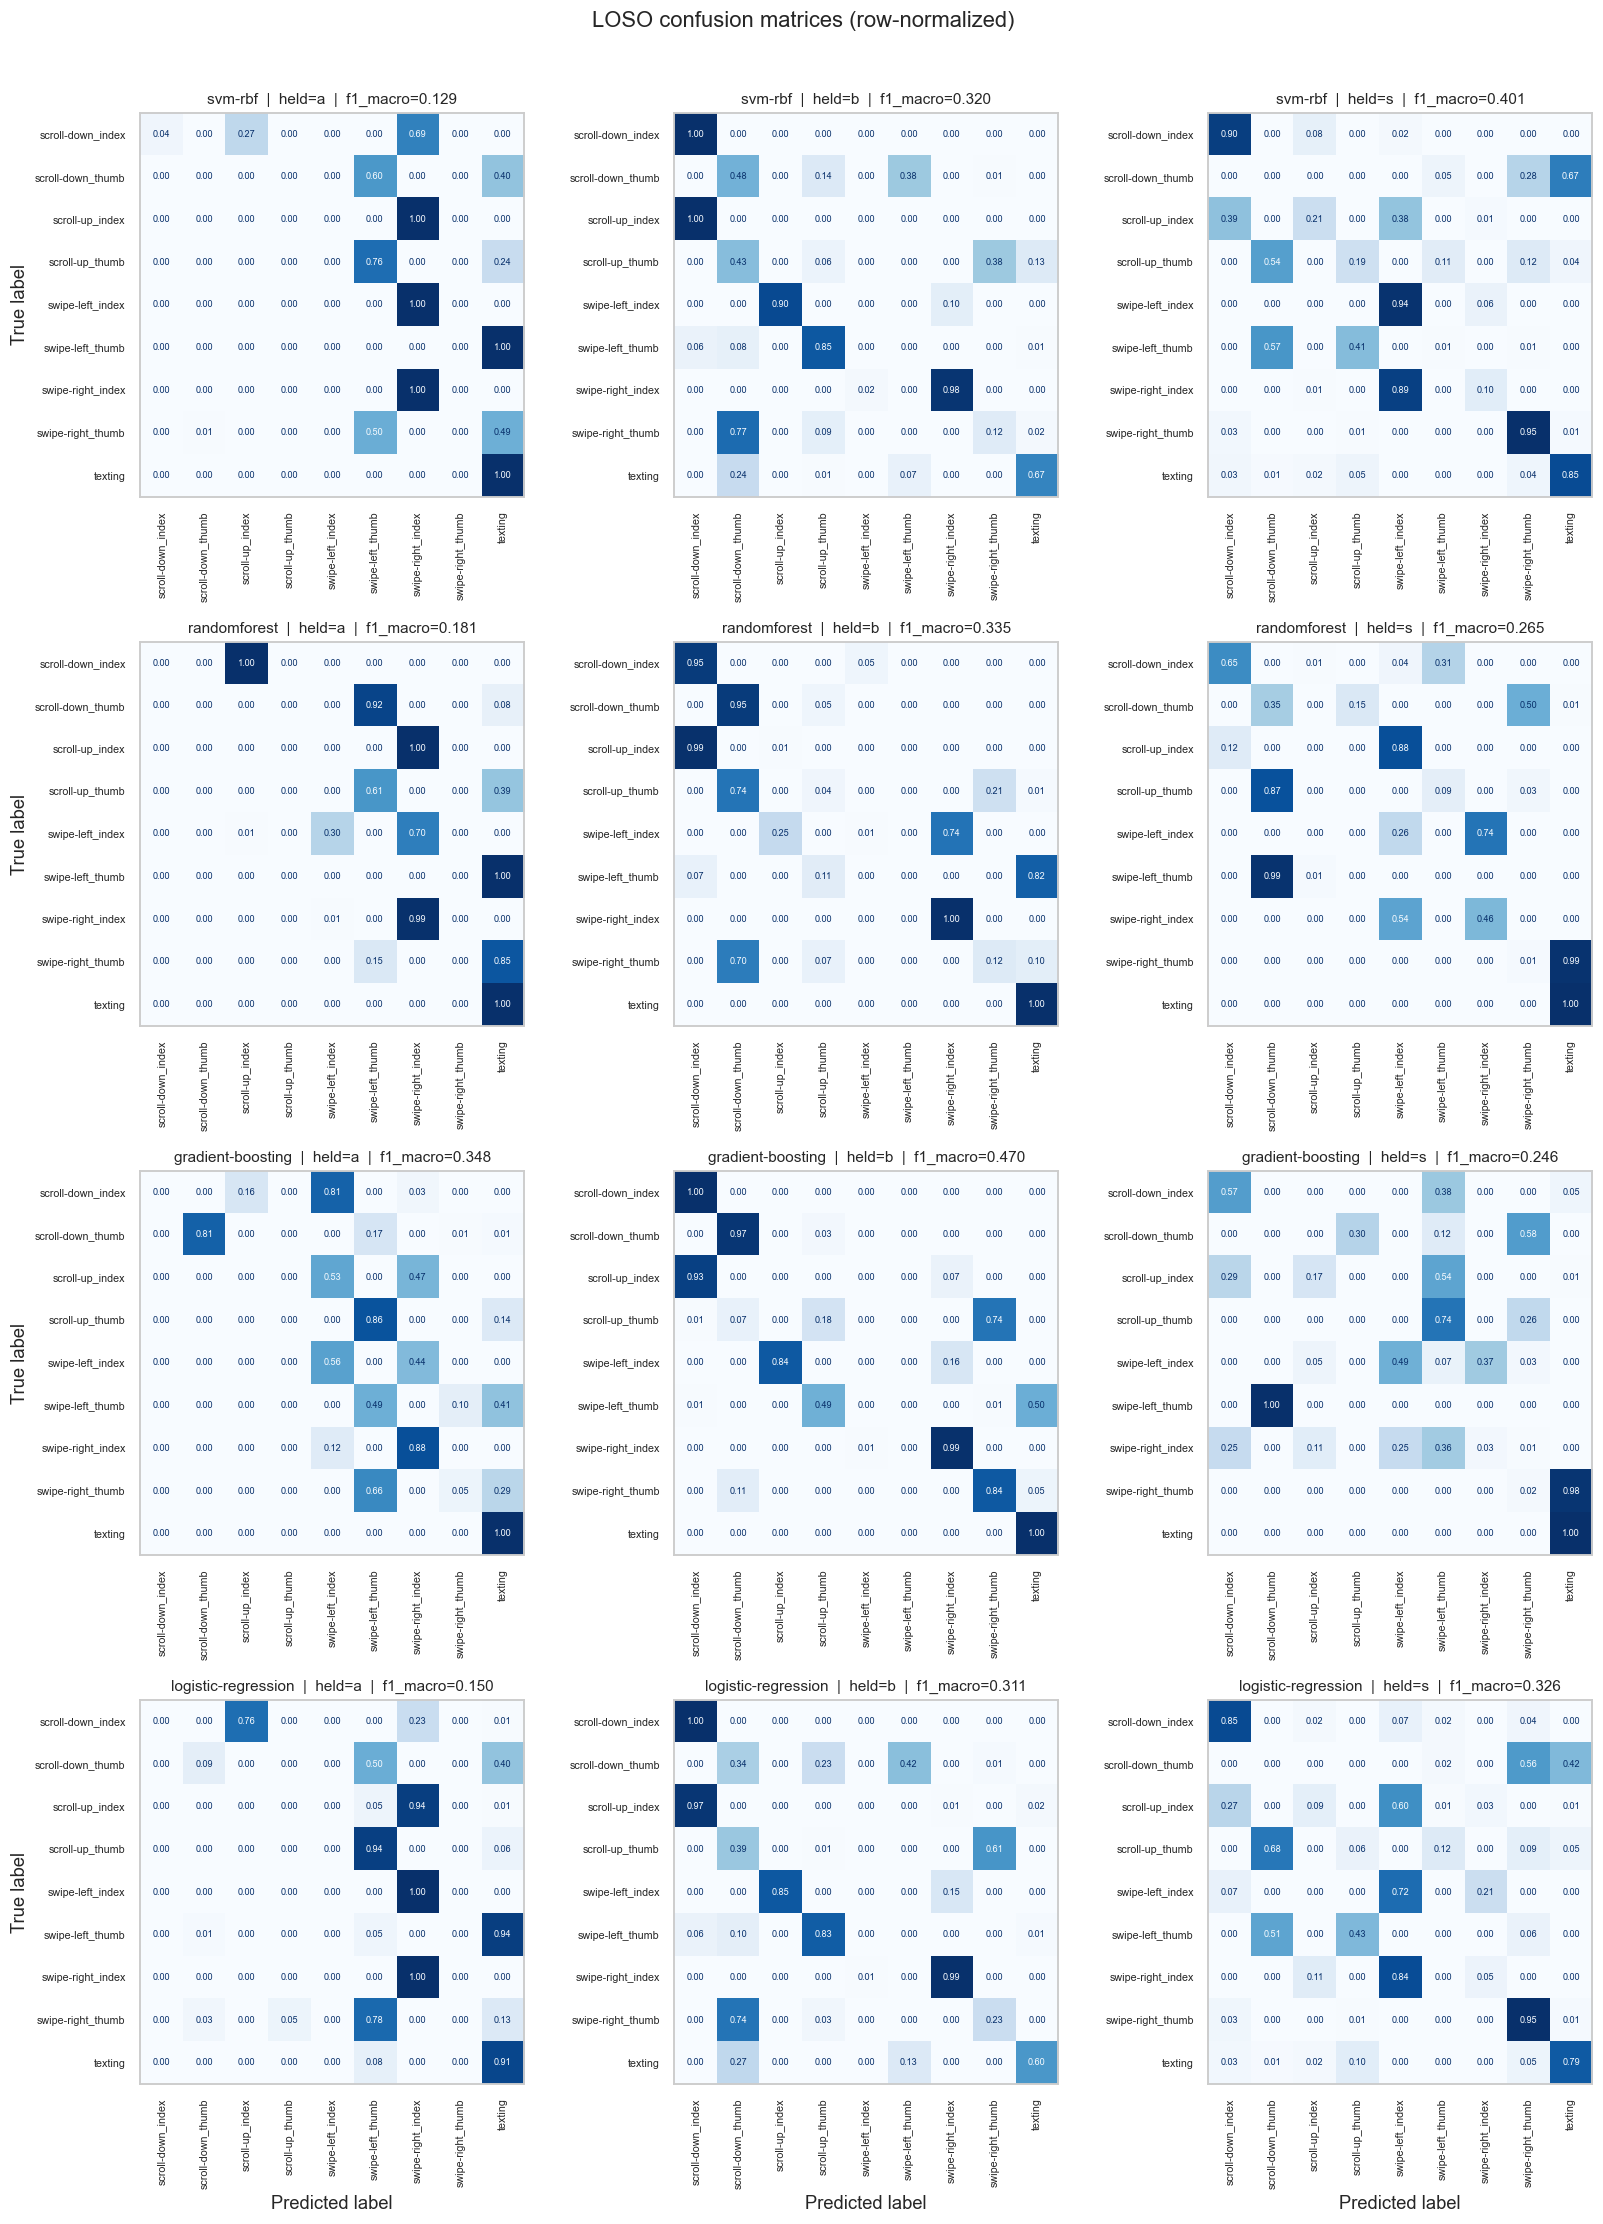

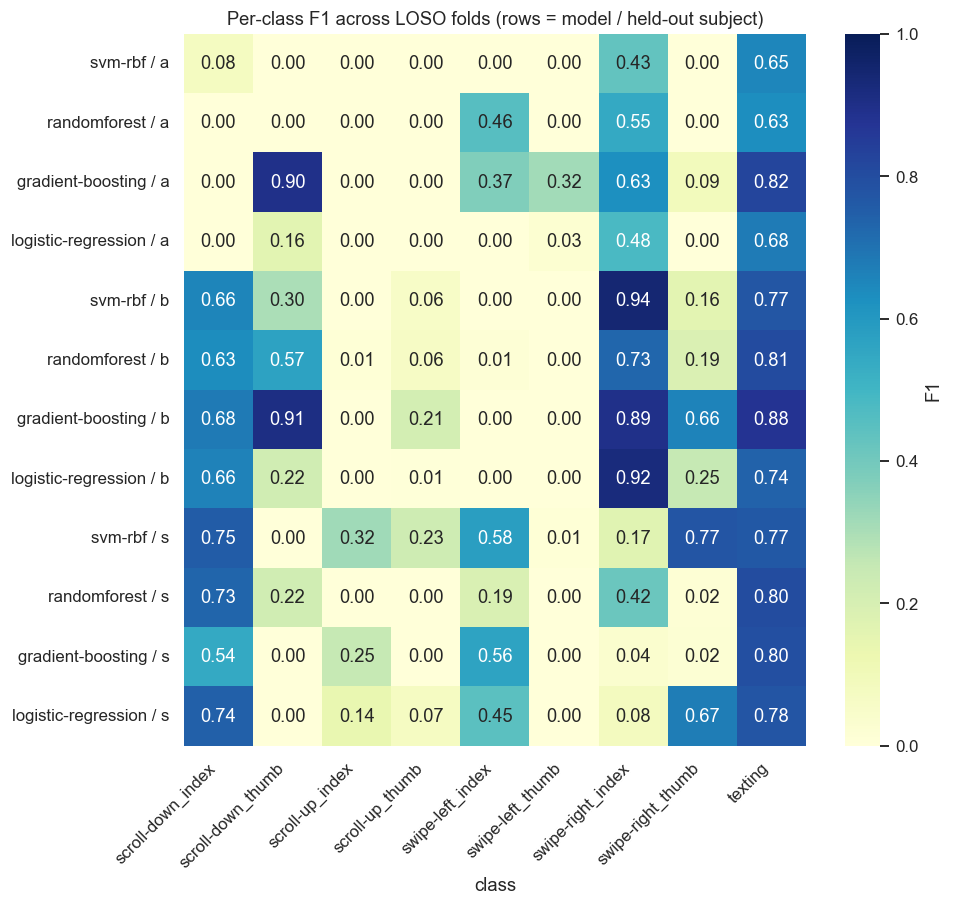


comparison_table.csv content:
              model pipeline held_out  accuracy  precision   recall  f1_weighted  f1_macro  cv_f1_macro                                                                       best_params
            svm-rbf features        a  0.304813   0.224428 0.304813     0.181324  0.128549     0.285036                       {"clf__C": 1000, "clf__gamma": 0.001, "clf__kernel": "rbf"}
       randomforest features        a  0.330882   0.228958 0.330882     0.227556  0.181395     0.207575   {"clf__max_depth": null, "clf__min_samples_split": 2, "clf__n_estimators": 200}
  gradient-boosting features        a  0.482620   0.375125 0.482620     0.397368  0.347754     0.135953   {"clf__l2_regularization": 0.0, "clf__learning_rate": 0.1, "clf__max_depth": 8}
logistic-regression features        a  0.298128   0.205295 0.298128     0.203585  0.150114     0.244608                       {"clf__C": 1, "clf__penalty": "l2", "clf__solver": "lbfgs"}
            svm-rbf features        b  

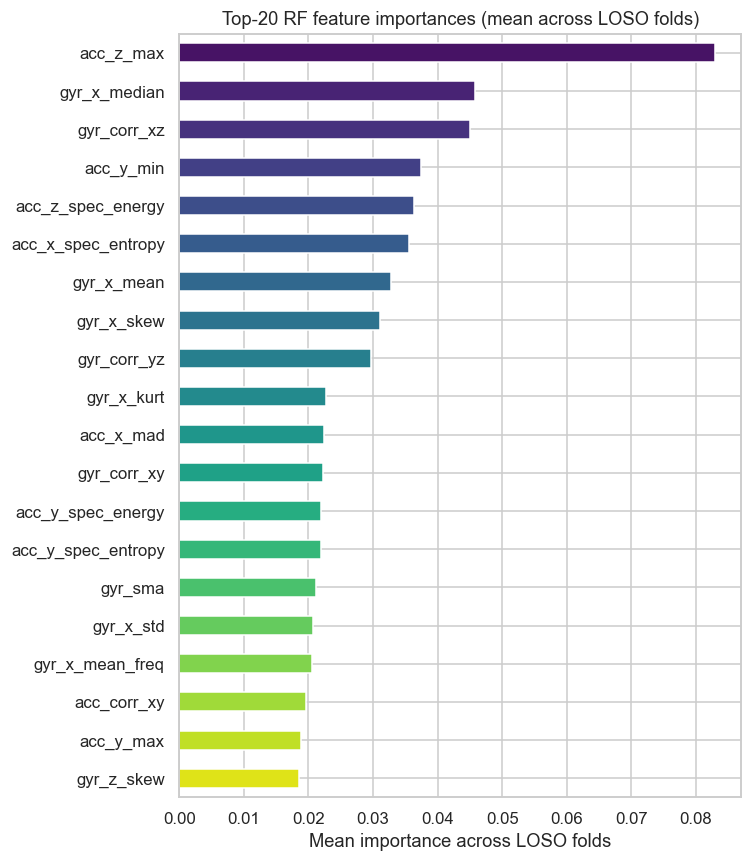

held=a: top-10 ANOVA vs RF overlap = 3/10  shared = ['acc_x_mad', 'acc_z_max', 'acc_z_spec_energy']
held=b: top-10 ANOVA vs RF overlap = 3/10  shared = ['acc_x_mad', 'acc_z_max', 'acc_z_rms']
held=s: top-10 ANOVA vs RF overlap = 2/10  shared = ['acc_z_max', 'acc_z_spec_energy']


WindowsPath('outputs/results/fe_anova_rf_overlap_loso.csv')

In [12]:
from sklearn.metrics import precision_recall_fscore_support

classes = sorted(np.unique(y))
model_names = list(variant_specs)

# ---- (a) per-fold breakdown rows ----
loso_rows = []
for held in SUBJECTS:
    for name in model_names:
        r = loso_results[held][name]
        metrics = evaluate_classifier(r["y_test"], r["y_pred"])
        loso_rows.append({
            "model":       name,
            "pipeline":    "features",
            "held_out":    held,
            **metrics,
            "cv_f1_macro": r["best_cv"],
            "best_params": json.dumps(r["best_params"]),
        })
loso_df = pd.DataFrame(loso_rows)[[
    "model", "pipeline", "held_out",
    "accuracy", "precision", "recall",
    "f1_weighted", "f1_macro", "cv_f1_macro", "best_params",
]]
save_results(loso_df, "fe_loso_results")
print("Per-fold LOSO breakdown:")
print(loso_df.to_string(index=False))

loso_mean = (loso_df.groupby("model")[["accuracy", "precision", "recall",
                                       "f1_weighted", "f1_macro", "cv_f1_macro"]]
                    .mean().round(3))
print("\nLOSO mean per model:")
print(loso_mean.to_string())

# ---- (b) confusion matrices: 2 (models) x 3 (held-out) ----
fig_cm, axes_cm = plt.subplots(len(model_names), len(SUBJECTS),
                                figsize=(5.0 * len(SUBJECTS),
                                         5.0 * len(model_names)))
axes_cm = np.atleast_2d(axes_cm)
for i, name in enumerate(model_names):
    for j, held in enumerate(SUBJECTS):
        r = loso_results[held][name]
        ax = axes_cm[i, j]
        ConfusionMatrixDisplay.from_predictions(
            r["y_test"], r["y_pred"], normalize="true",
            labels=classes, ax=ax,
            xticks_rotation="vertical", colorbar=False, cmap="Blues",
            values_format=".2f",
        )
        f1m = f1_score(r["y_test"], r["y_pred"], average="macro")
        ax.set_title(f"{name}  |  held={held}  |  f1_macro={f1m:.3f}",
                     fontsize=10)
        ax.grid(False)
        # 9 class names are long; shrink tick labels (predicted axis is vertical)
        # and the in-cell numbers so nothing overlaps.
        ax.tick_params(axis="both", labelsize=7)
        for _t in ax.texts:
            _t.set_fontsize(6)
        if j > 0:
            ax.set_ylabel("")
        if i < len(model_names) - 1:
            ax.set_xlabel("")
fig_cm.suptitle("LOSO confusion matrices (row-normalized)", y=1.01)
fig_cm.tight_layout()
save_figure(fig_cm, "fe_cm_loso")
plt.show()
plt.close(fig_cm)

# ---- (c) per-class F1 heatmap ----
per_class_rows = []
for held in SUBJECTS:
    for name in model_names:
        r = loso_results[held][name]
        _, _, f1_per_class, _ = precision_recall_fscore_support(
            r["y_test"], r["y_pred"], labels=classes, zero_division=0)
        per_class_rows.append({
            "model_held": f"{name} / {held}",
            **dict(zip(classes, f1_per_class)),
        })
per_class_df = pd.DataFrame(per_class_rows).set_index("model_held")
save_results(per_class_df.reset_index(), "fe_per_class_f1_loso")

fig_pc, ax_pc = plt.subplots(figsize=(9, 0.55 * len(per_class_df) + 1.8))
sns.heatmap(per_class_df, annot=True, fmt=".2f", cmap="YlGnBu",
            vmin=0, vmax=1, ax=ax_pc, cbar_kws={"label": "F1"})
ax_pc.set_xlabel("class")
ax_pc.set_ylabel("")
# Class names are long; rotate x ticks so they do not overlap.
ax_pc.set_xticklabels(ax_pc.get_xticklabels(), rotation=45, ha="right")
ax_pc.set_title("Per-class F1 across LOSO folds (rows = model / held-out subject)")
fig_pc.tight_layout()
save_figure(fig_pc, "fe_per_class_f1_loso")
plt.show()
plt.close(fig_pc)

# ---- (d) update comparison_table.csv (schema: model, pipeline, held_out, metrics, best_params) ----
ct_cols = ["model", "pipeline", "held_out", "accuracy", "precision", "recall",
           "f1_weighted", "f1_macro", "cv_f1_macro", "best_params"]
ct_path = Path(cfg["out_results"]) / "comparison_table.csv"
if ct_path.exists():
    existing = pd.read_csv(ct_path)
    if "held_out" not in existing.columns:
        existing["held_out"] = ""
    existing = existing[existing["pipeline"] != "features"]
    for col in ct_cols:
        if col not in existing.columns:
            existing[col] = pd.NA
    existing = existing[ct_cols]
    combined = pd.concat([existing, loso_df[ct_cols]], ignore_index=True)
else:
    combined = loso_df[ct_cols]
save_results(combined, "comparison_table")
print("\ncomparison_table.csv content:")
print(combined.to_string(index=False))

# ---- (e) RF feature importance averaged across folds ----
rf_importances = []
for held in SUBJECTS:
    r = loso_results[held]["randomforest"]
    rf = r["fitted"].named_steps["clf"]
    rf_importances.append(pd.Series(rf.feature_importances_,
                                    index=r["feature_names"]))
rf_fi_mean = (pd.concat(rf_importances, axis=1)
                .fillna(0.0)
                .mean(axis=1)
                .sort_values(ascending=False))

fig_fi, ax_fi = plt.subplots(figsize=(7, 8))
rf_fi_mean.head(20).plot.barh(ax=ax_fi,
                              color=sns.color_palette("viridis", 20))
ax_fi.invert_yaxis()
ax_fi.set_xlabel("Mean importance across LOSO folds")
ax_fi.set_title("Top-20 RF feature importances (mean across LOSO folds)")
fig_fi.tight_layout()
save_figure(fig_fi, "fe_rf_feature_importance_top20")
plt.show()
plt.close(fig_fi)

# ---- (f) ANOVA vs RF importance cross-check, per fold (train-only) ----
overlap_rows = []
for held in SUBJECTS:
    top_anova_fold = set(folds[held]["anova"].head(10)["feature"])
    rf_fi_fold = pd.Series(
        loso_results[held]["randomforest"]["fitted"].named_steps["clf"].feature_importances_,
        index=loso_results[held]["randomforest"]["feature_names"],
    )
    top_rf_fold = set(rf_fi_fold.sort_values(ascending=False).head(10).index)
    shared = sorted(top_anova_fold & top_rf_fold)
    overlap_rows.append({
        "held_out": held,
        "anova_rf_top10_overlap": len(shared),
        "shared_features": ", ".join(shared),
    })
    print(f"held={held}: top-10 ANOVA vs RF overlap = {len(shared)}/10  "
          f"shared = {shared}")
save_results(pd.DataFrame(overlap_rows), "fe_anova_rf_overlap_loso")


# 12. Tier-2 extras: PCA + Linear-SVM baseline (LOSO)

## Σκοπός
Sanity baseline που χρησιμοποιεί **unsupervised dimensionality reduction (PCA)** πριν από έναν απλό linear classifier (SVM με linear kernel). Το PCA συμπιέζει το feature space σε `k` components που εξηγούν 95% της variance, και ο linear SVM δοκιμάζει αν αυτές οι κατευθύνσεις (που μεγιστοποιούν variance, όχι class separation) έχουν αρκετή discriminative δομή.

## Γιατί baseline και όχι ανταγωνιστής
- Αν το `PCA + Linear-SVM` φτάσει κοντά στο `RBF-SVM` ή στο `RF`, η ένδειξη είναι ότι το πρόβλημα είναι ουσιαστικά γραμμικά διαχωρίσιμο στο engineered feature space.
- Αν είναι πολύ χειρότερο, η non-linearity του RBF kernel και η axis-aligned partitioning των trees είναι σημαντικές - επιβεβαιώνει την επιλογή τους.

Είναι ακριβώς το διαγνωστικό που προτείνει η βιβλιογραφία: *"Many correlated feats → PCA + linear model"*. Το PCA συμπτύσσει τα correlated groups σε λίγες κατευθύνσεις και ο linear classifier αξιολογεί αν αυτό αρκεί.

## Τρέχει σε LOSO όπως το main loop
Ίδιο 3-fold scheme· τα αποτελέσματα αποθηκεύονται κάτω από `outputs/results/extras/`, ώστε να μην ανακατεύονται με την κύρια comparison table. Τα παρατηρούμενα `f1_macro` είναι **0.129 για held=a** (23 components), **0.367 για held=b** (24 components) και **0.478 για held=s** (24 components) - συγκρίσιμα με τα κύρια μοντέλα του cell 10 (για held=s μάλιστα το 0.478 είναι από τα υψηλότερα όλων), επιβεβαιώνοντας ότι το πρόβλημα δεν είναι κυρίως non-linear, αλλά κυρίως subject-variance-bound.


held=a: f1_macro=0.129  components=23
held=b: f1_macro=0.367  components=24
held=s: f1_macro=0.478  components=24


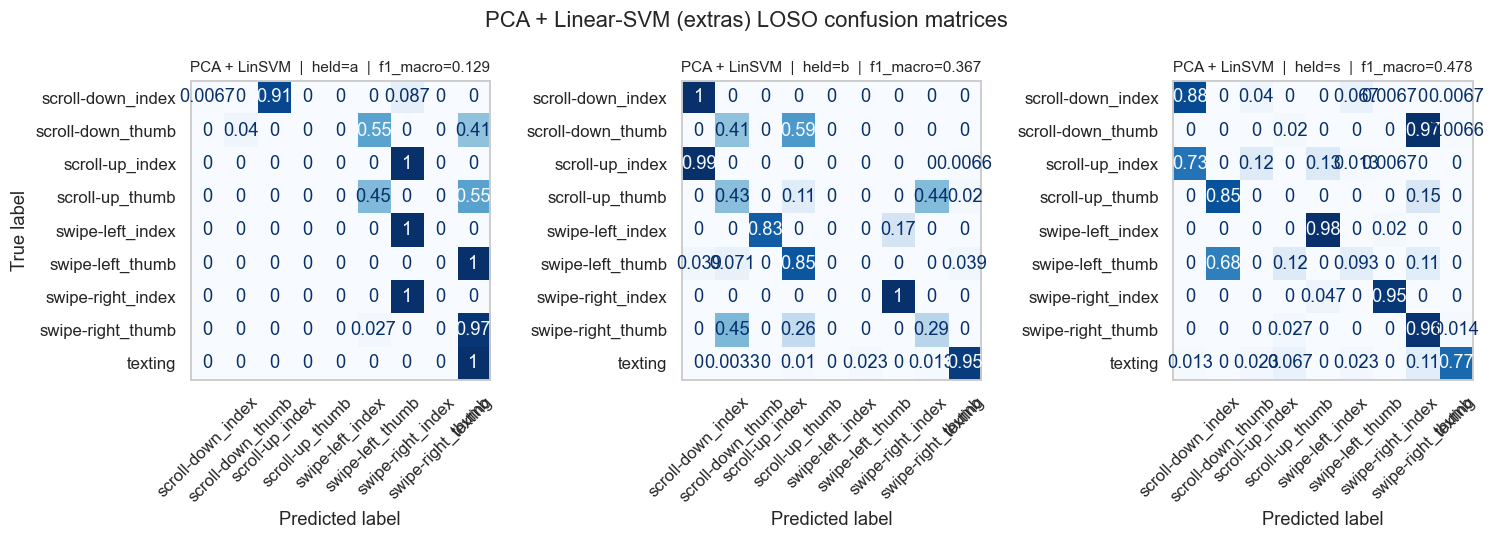

In [13]:
extras_dir = Path(cfg["out_results"]) / "extras"
extras_dir.mkdir(parents=True, exist_ok=True)

extras_rows = []
fig_ex, axes_ex = plt.subplots(1, len(SUBJECTS), figsize=(4.6 * len(SUBJECTS), 4.6))
axes_ex = np.atleast_1d(axes_ex)
for j, held in enumerate(SUBJECTS):
    fold = folds[held]
    X_tr, X_te = fold["X_tr"], fold["X_te"]
    y_tr, y_te = fold["y_tr"], fold["y_te"]

    pre = build_preprocessor(X_tr.columns)
    pipe_pca = Pipeline([
        ("pre", pre),
        ("pca", PCA(n_components=cfg["PCA"]["n_comp"])),
        ("clf", SVC(class_weight="balanced", kernel="linear",
                    random_state=cfg["random_state"])),
    ])
    pipe_pca.fit(X_tr, y_tr)
    y_pred_pca = pipe_pca.predict(X_te)
    metrics = evaluate_classifier(y_te, y_pred_pca)
    extras_rows.append({"held_out": held,
                         "model": "pca-linsvm",
                         "pipeline": "features-extras",
                         "n_components": int(pipe_pca.named_steps["pca"].n_components_),
                         **metrics})
    print(f"held={held}: f1_macro={metrics['f1_macro']:.3f}  "
          f"components={pipe_pca.named_steps['pca'].n_components_}")

    ax = axes_ex[j]
    ConfusionMatrixDisplay.from_predictions(
        y_te, y_pred_pca, normalize="true", labels=classes,
        ax=ax, xticks_rotation=45, colorbar=False, cmap="Blues",
    )
    ax.set_title(f"PCA + LinSVM  |  held={held}  |  f1_macro={metrics['f1_macro']:.3f}",
                 fontsize=10)
    ax.grid(False)
    if j > 0:
        ax.set_ylabel("")
fig_ex.suptitle("PCA + Linear-SVM (extras) LOSO confusion matrices", y=1.02)
fig_ex.tight_layout()
fig_ex.savefig(extras_dir / "cm_features_pca_linsvm_loso.png",
               dpi=150, bbox_inches="tight")
plt.show()
plt.close(fig_ex)

pd.DataFrame(extras_rows).to_csv(
    extras_dir / "fe_pca_linsvm_loso_metrics.csv", index=False)


# 12b. Persist `results_fe.pkl`

Αποθηκεύει per-fold per-model `best_params`, `best_cv`, `y_pred`, `y_test`, `feature_names` και `drops`, με τον fitted estimator stripped ώστε το pickle να μένει μικρό. Ο κώδικας comparison downstream μπορεί να φορτώσει αυτό το αρχείο χωρίς να ξανατρέξει το training και να ανακτήσει τις per-window predictions για οποιοδήποτε cross-pipeline diagnostic. Συμμετρικό με το `outputs/cache/results_ts.pkl`.


In [14]:
results_fe_serializable = {
    held: {
        name: {k: v for k, v in entry.items() if k != "fitted"}
        for name, entry in by_model.items()
    }
    for held, by_model in loso_results.items()
}

out_cache = Path(cfg["out_cache"])
out_cache.mkdir(parents=True, exist_ok=True)
pkl_path = out_cache / "results_fe.pkl"
with open(pkl_path, "wb") as f:
    pickle.dump(results_fe_serializable, f)

print(f"Saved {pkl_path}")
for held in SUBJECTS:
    for name in variant_specs:
        r = results_fe_serializable[held][name]
        print(f"  held={held}  model={name:>20s}  cv_f1_macro={r['best_cv']:.3f}  y_pred.shape={r['y_pred'].shape}")


Saved outputs\cache\results_fe.pkl
  held=a  model=             svm-rbf  cv_f1_macro=0.285  y_pred.shape=(1496,)
  held=a  model=        randomforest  cv_f1_macro=0.208  y_pred.shape=(1496,)
  held=a  model=   gradient-boosting  cv_f1_macro=0.136  y_pred.shape=(1496,)
  held=a  model= logistic-regression  cv_f1_macro=0.245  y_pred.shape=(1496,)
  held=b  model=             svm-rbf  cv_f1_macro=0.333  y_pred.shape=(1516,)
  held=b  model=        randomforest  cv_f1_macro=0.143  y_pred.shape=(1516,)
  held=b  model=   gradient-boosting  cv_f1_macro=0.236  y_pred.shape=(1516,)
  held=b  model= logistic-regression  cv_f1_macro=0.343  y_pred.shape=(1516,)
  held=s  model=             svm-rbf  cv_f1_macro=0.267  y_pred.shape=(1494,)
  held=s  model=        randomforest  cv_f1_macro=0.296  y_pred.shape=(1494,)
  held=s  model=   gradient-boosting  cv_f1_macro=0.275  y_pred.shape=(1494,)
  held=s  model= logistic-regression  cv_f1_macro=0.248  y_pred.shape=(1494,)


# 13. Συμπεράσματα και περιορισμοί

## Τι δουλεύει
- Το engineered feature space είναι **fully discriminative within subject** (`f1_macro = 1.000` σε intra-subject 80/20 stratified split).
- Το LOSO τρέχει καθαρά και παράγει 3 ανεξάρτητα test scores ανά μοντέλο, συνολικά **12 fits για τους 4 ταξινομητές** (SVM-RBF, Random Forest, Gradient Boosting, Logistic Regression).
- Το `ColumnTransformer + Pipeline` εξασφαλίζει zero scaler leakage: ο scaler κάνει `fit` μόνο στο train fold.
- Το per-fold pruning αποφεύγει να ενημερωθεί από τα labels του held-out subject (αυστηρή απουσία supervised leakage).

## Τι περιορίζει την απόδοση
- **N = 3 subjects** είναι κάτω από το threshold όπου ένα μοντέλο μπορεί να μάθει subject-invariant representation. Οι LOSO mean test `f1_macro` τιμές είναι **0.283 (SVM-RBF)**, **0.260 (Random Forest)**, **0.355 (Gradient Boosting)** και **0.263 (Logistic Regression)** - με τις 9 classes το **Gradient Boosting** είναι πλέον το καλύτερο μοντέλο κατά μέσο όρο. Το per-fold spread κυμαίνεται από **0.129 (SVM-RBF, held=a)** έως **0.470 (Gradient Boosting, held=b)**. Κατά μέσο όρο ανά fold, ο `a` είναι ο δυσκολότερος held-out subject (mean ≈ 0.20) και ο `b` ο ευκολότερος (mean ≈ 0.36), με τον `s` ενδιάμεσο (≈ 0.31). Ανά μοντέλο η εικόνα διαφέρει: SVM-RBF και Logistic Regression κορυφώνονται στον `s` (0.401 και 0.326), ενώ Random Forest και Gradient Boosting στον `b` (0.335 και 0.470).
- Η inter-subject variance υπερβαίνει την inter-class variance. Από το per-class F1 heatmap (9 classes) φαίνεται καθαρά: το `texting` είναι σταθερά η ισχυρότερη κλάση (mean F1 ≈ 0.76, εύρος 0.63 έως 0.88), λόγω του διακριτού two-handed motion. Ακολουθούν τα **index-finger variants**: `swipe-right_index` (mean 0.52, max 0.94) και `scroll-down_index` (mean 0.46, max 0.75). Κρίσιμη παρατήρηση που αναδεικνύει το 9-class setup: για κάθε χειρονομία το index variant γενικεύει καλύτερα από το thumb variant (scroll-down: index 0.46 vs thumb 0.27· swipe-right: 0.52 vs 0.24· swipe-left: 0.22 vs 0.03). Οι κλάσεις `scroll-up_thumb` και `scroll-up_index` (mean ≈ 0.05) και το `swipe-left_thumb` (mean 0.03) σχεδόν καταρρέουν cross-subject, υποδεικνύοντας ότι ο τρόπος εκτέλεσής τους εξαρτάται έντονα από τον χρήστη.
- Με 2 train subjects, το `GridSearchCV(GroupKFold(2))` είναι noisy point estimator και συστηματικά επιλέγει over-regularized hyperparameters.
- Η correlation pruning αφαιρεί **34 features για held=a**, **39 για held=b** και **44 για held=s** από τα 102 αρχικά. Τα samples/features ratios μετά το pruning είναι εύρωστα (> 44 και στις τρεις folds).

## Findings που αξίζει να αναφερθούν στο report
1. **Within-subject ceiling 1.000** (επιβεβαιωμένο και για τις 9 classes, και στους τρεις subjects) vs **cross-subject LOSO mean 0.26 έως 0.36** ποσοτικοποιεί σαφώς το inter-subject generalization gap.
2. **Per-LOSO breakdown** δείχνει ότι κάθε subject έχει διαφορετική δυσκολία. Ένα μοναδικό fixed split θα έδινε παραπλανητική εικόνα.
3. **Per-class F1 pattern (9 classes)**: το `texting` ισχυρό, τα index variants (ειδικά `swipe-right_index`, `scroll-down_index`) αξιοπρεπή, ενώ τα thumb variants και ιδίως το `scroll-up` (και στα δύο δάχτυλα) σχεδόν αποτυγχάνουν cross-subject. Τα index δάχτυλα γενικεύουν συστηματικά καλύτερα από τα thumb. Σήμα ότι το data collection χρειάζεται πιο τυποποιημένο πρωτόκολλο, ειδικά για τις thumb εκτελέσεις.
4. **ANOVA vs RF top-10 overlap**: 3 κοινά features για held=a, 3 για held=b, 2 για held=s (μέσος όρος περίπου 2.7 από 10). Το χαμηλό overlap δείχνει ότι η discriminative δομή είναι μη γραμμική και ευθυγραμμίζεται με την επιλογή RBF kernel και tree-based μοντέλων.

## Πιθανές επόμενες κινήσεις (εκτός scope του παρόντος notebook)
- Συλλογή δεδομένων από 5+ επιπλέον subjects, ώστε ο classifier να μπορέσει να μάθει subject-invariant features.
- Subject-adaptive σχήματα: per-user calibration, domain adaptation, transfer learning.
- Σύγκριση με end-to-end deep model (raw time-series pipeline) στο ίδιο LOSO scheme, ώστε να διαπιστωθεί αν deep representations είναι πιο subject-robust από handcrafted features.
